In [ ]:
# ============================================================
# CELL 1: IMPORT LIBRARIES, DEFINE SETTINGS AND METRICS
# ============================================================



import ast
import json
import random
import time
import warnings
from itertools import product
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import requests
import holidays

from IPython.display import display
from scipy import stats

from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import StandardScaler, MinMaxScaler

from statsmodels.graphics.gofplots import qqplot
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tsa.statespace.sarimax import SARIMAX


# Hide unnecessary model warnings while keeping explicit errors visible.
warnings.filterwarnings("ignore")


# -----------------------------
# Reproducibility configuration
# -----------------------------

RANDOM_STATE = 42

np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)


# -----------------------------
# Assignment settings
# -----------------------------

DATA_URL = (
    "https://data.open-power-system-data.org/time_series/"
    "2020-10-06/time_series_60min_singleindex.csv"
)

LOAD_COLUMN = "DE_load_actual_entsoe_transparency"

START_DATE = "2015-01-01"

# Final 104 complete weeks represent the required two-year test horizon.
TEST_WEEKS = 104

# Weekly annual seasonality is approximately 52 weeks.
SEASONAL_PERIOD = 52

# Degree-day thresholds used for temperature feature engineering.
HEATING_BASE = 15.5
COOLING_BASE = 22.0


# Set these to False only when previously saved results are available.
RUN_SARIMA_SEARCH = True
RUN_QUANTILE_TUNING = True
RUN_LSTM = True


# -----------------------------
# Output folders
# -----------------------------

RESULTS_DIR = Path("results")
FIGURES_DIR = Path("figures")

RESULTS_DIR.mkdir(exist_ok=True)
FIGURES_DIR.mkdir(exist_ok=True)


# -----------------------------
# Plot settings
# -----------------------------

plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.size"] = 11
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25


# ============================================================
# FORECAST EVALUATION FUNCTIONS
# ============================================================

def calculate_rmse(y_true, y_pred):
    """
    Calculate root mean squared error.

    RMSE penalises large errors more strongly than MAE.
    """
    return float(
        np.sqrt(
            mean_squared_error(
                np.asarray(y_true),
                np.asarray(y_pred)
            )
        )
    )


def calculate_smape(y_true, y_pred):
    """
    Calculate symmetric mean absolute percentage error.

    The result is reported as a percentage.
    """
    actual = np.asarray(y_true, dtype=float)
    forecast = np.asarray(y_pred, dtype=float)

    denominator = np.abs(actual) + np.abs(forecast)

    valid = denominator > 0

    return float(
        200
        * np.mean(
            np.abs(forecast[valid] - actual[valid])
            / denominator[valid]
        )
    )


def calculate_mase(y_true, y_pred, training_series, seasonality=52):
    """
    Calculate mean absolute scaled error.

    The scaling denominator uses a seasonal-naive error calculated
    from the training data only.
    """
    training_values = np.asarray(training_series, dtype=float)

    seasonal_errors = np.abs(
        training_values[seasonality:]
        - training_values[:-seasonality]
    )

    scaling_value = seasonal_errors.mean()

    if scaling_value == 0:
        return np.nan

    model_error = np.mean(
        np.abs(
            np.asarray(y_true, dtype=float)
            - np.asarray(y_pred, dtype=float)
        )
    )

    return float(model_error / scaling_value)


def evaluate_point_forecast(
    model_name,
    actual,
    forecast,
    training_series
):
    """
    Return the main point-forecast metrics required for comparison.

    Bias is defined as:
        forecast - actual

    Negative bias means that the model tends to underforecast demand.
    """
    actual = pd.Series(actual).astype(float)

    forecast = pd.Series(
        np.asarray(forecast, dtype=float),
        index=actual.index
    )

    return {
        "Model": model_name,
        "MAE": mean_absolute_error(actual, forecast),
        "RMSE": calculate_rmse(actual, forecast),
        "sMAPE (%)": calculate_smape(actual, forecast),
        "MASE": calculate_mase(
            actual,
            forecast,
            training_series,
            SEASONAL_PERIOD
        ),
        "Bias (forecast - actual)": float(
            (forecast - actual).mean()
        )
    }


def calculate_interval_score(
    actual,
    lower,
    upper,
    alpha
):
    """
    Calculate the interval score.

    The interval score penalises:
    1. unnecessarily wide intervals;
    2. observations below the lower boundary;
    3. observations above the upper boundary.

    Lower values indicate better interval performance.
    """
    actual = np.asarray(actual, dtype=float)
    lower = np.asarray(lower, dtype=float)
    upper = np.asarray(upper, dtype=float)

    score = upper - lower

    below_penalty = (
        (2 / alpha)
        * (lower - actual)
        * (actual < lower)
    )

    above_penalty = (
        (2 / alpha)
        * (actual - upper)
        * (actual > upper)
    )

    return score + below_penalty + above_penalty


def evaluate_prediction_interval(
    model_name,
    nominal_coverage,
    actual,
    lower,
    upper
):
    """
    Evaluate prediction-interval calibration and sharpness.

    PICP:
        Proportion of observations inside the interval.

    MPIW:
        Mean width of the prediction interval.
    """
    actual = pd.Series(actual).astype(float)

    lower = pd.Series(
        np.asarray(lower, dtype=float),
        index=actual.index
    )

    upper = pd.Series(
        np.asarray(upper, dtype=float),
        index=actual.index
    )

    inside_interval = (
        (actual >= lower)
        & (actual <= upper)
    )

    below_interval = actual < lower
    above_interval = actual > upper

    alpha = 1 - nominal_coverage

    return {
        "Model": model_name,
        "Nominal coverage": nominal_coverage,
        "Actual coverage (PICP)": inside_interval.mean(),
        "Coverage difference": (
            inside_interval.mean() - nominal_coverage
        ),
        "Mean interval width (MPIW)": (
            upper - lower
        ).mean(),
        "Mean interval score": calculate_interval_score(
            actual,
            lower,
            upper,
            alpha
        ).mean(),
        "Below lower boundary": int(
            below_interval.sum()
        ),
        "Above upper boundary": int(
            above_interval.sum()
        )
    }


def create_residual_diagnostics(model_name, fitted_model):
    """
    Produce residual summary statistics and Ljung-Box test results.
    """
    residuals = pd.Series(
        fitted_model.resid
    ).dropna().astype(float)

    # Remove an initial burn-in period affected by model initialisation.
    burn_in = max(
        int(
            getattr(
                fitted_model,
                "loglikelihood_burn",
                0
            )
        ),
        SEASONAL_PERIOD
    )

    if len(residuals) > burn_in + 20:
        residuals = residuals.iloc[burn_in:]

    valid_lags = [
        lag
        for lag in [10, 20, 52]
        if lag < len(residuals) - 1
    ]

    ljung_box = acorr_ljungbox(
        residuals,
        lags=valid_lags,
        return_df=True
    )

    diagnostics = {
        "Model": model_name,
        "Residual mean": residuals.mean(),
        "Residual standard deviation": residuals.std(),
        "Residual skewness": stats.skew(
            residuals,
            bias=False
        ),
        "Residual kurtosis": stats.kurtosis(
            residuals,
            bias=False
        )
    }

    for lag in valid_lags:
        diagnostics[
            f"Ljung-Box p-value lag {lag}"
        ] = ljung_box.loc[lag, "lb_pvalue"]

    return diagnostics, residuals

In [ ]:
# ============================================================
# CELL 2: DOWNLOAD AND PREPARE GERMAN ELECTRICITY LOAD
# ============================================================

def convert_to_weekly_mean(series):
    """
    Aggregate an hourly or daily series into Monday-Sunday weeks.

    Each weekly observation is labelled using the Sunday at the
    end of that week.
    """
    weekly_period = series.index.to_period("W-SUN")

    weekly_series = series.groupby(
        weekly_period
    ).mean()

    weekly_series.index = (
        weekly_series.index
        .end_time
        .normalize()
    )

    weekly_series.index.name = "week"

    return weekly_series


# -----------------------------
# Download required columns
# -----------------------------

raw_load = pd.read_csv(
    DATA_URL,
    usecols=[
        "utc_timestamp",
        LOAD_COLUMN
    ]
)


# -----------------------------
# Prepare the timestamp
# -----------------------------

raw_load["utc_timestamp"] = (
    pd.to_datetime(
        raw_load["utc_timestamp"],
        utc=True
    )
    .dt.tz_convert(None)
)

raw_load = raw_load.rename(
    columns={
        "utc_timestamp": "date",
        LOAD_COLUMN: "load_mw"
    }
)

raw_load = (
    raw_load
    .set_index("date")
    .sort_index()
)


# -----------------------------
# Check duplicate timestamps
# -----------------------------

duplicate_count = int(
    raw_load.index.duplicated().sum()
)

raw_load = raw_load[
    ~raw_load.index.duplicated(
        keep="first"
    )
]


# -----------------------------
# Keep data from January 2015
# -----------------------------

load_mw = pd.to_numeric(
    raw_load["load_mw"],
    errors="coerce"
)

load_mw = load_mw.loc[START_DATE:]


# -----------------------------
# Create a complete hourly index
# -----------------------------

complete_hourly_index = pd.date_range(
    start=load_mw.index.min().floor("h"),
    end=load_mw.index.max().floor("h"),
    freq="h"
)

load_mw = load_mw.reindex(
    complete_hourly_index
)

load_mw.index.name = "date"


# Record missing data before interpolation.
missing_before_interpolation = int(
    load_mw.isna().sum()
)


# -----------------------------
# Handle missing hourly values
# -----------------------------

# Short missing gaps are interpolated using time-based interpolation.
load_mw = load_mw.interpolate(
    method="time",
    limit=6
)

missing_after_short_interpolation = int(
    load_mw.isna().sum()
)

# Fill any remaining longer gaps only after recording their number.
load_mw = (
    load_mw
    .interpolate(method="time")
    .ffill()
    .bfill()
)


# Convert megawatts to gigawatts for clearer plots and tables.
hourly_load = load_mw / 1000

hourly_load.name = "load_gw"


# -----------------------------
# Create daily data
# -----------------------------

daily_load = hourly_load.resample(
    "D"
).mean()

daily_load.name = "load_gw"


# -----------------------------
# Create weekly data
# -----------------------------

week_periods = hourly_load.index.to_period(
    "W-SUN"
)

weekly_load = hourly_load.groupby(
    week_periods
).mean()

weekly_hour_count = pd.Series(
    1,
    index=hourly_load.index
).groupby(
    week_periods
).sum()


# Retain only complete 168-hour weeks.
complete_week_mask = (
    weekly_hour_count == 168
)

weekly_load = weekly_load.loc[
    complete_week_mask
]

weekly_load.index = (
    weekly_load.index
    .end_time
    .normalize()
)

weekly_load.index.name = "week"

weekly_load.name = "load_gw"


# -----------------------------
# Define the chronological split
# -----------------------------

if len(weekly_load) <= TEST_WEEKS + SEASONAL_PERIOD:
    raise ValueError(
        "The weekly series is too short for the "
        "requested 104-week test horizon."
    )

train = weekly_load.iloc[
    :-TEST_WEEKS
].copy()

test = weekly_load.iloc[
    -TEST_WEEKS:
].copy()


# -----------------------------
# Data-quality summary
# -----------------------------

data_quality_table = pd.DataFrame(
    {
        "Check": [
            "Raw rows downloaded",
            "Duplicate timestamps removed",
            "Missing values before interpolation",
            "Missing after short interpolation",
            "Final hourly observations",
            "Daily observations",
            "Complete weekly observations",
            "Training weeks",
            "Testing weeks",
            "Training start",
            "Training end",
            "Testing start",
            "Testing end"
        ],
        "Result": [
            len(raw_load),
            duplicate_count,
            missing_before_interpolation,
            missing_after_short_interpolation,
            len(hourly_load),
            len(daily_load),
            len(weekly_load),
            len(train),
            len(test),
            str(train.index.min().date()),
            str(train.index.max().date()),
            str(test.index.min().date()),
            str(test.index.max().date())
        ]
    }
)

display(data_quality_table)

print(
    f"Training period: "
    f"{train.index.min().date()} to "
    f"{train.index.max().date()}"
)

print(
    f"Testing period: "
    f"{test.index.min().date()} to "
    f"{test.index.max().date()}"
)

,Check,Result
0,Raw rows downloaded,50401
1,Duplicate timestamps removed,0
2,Missing values before interpolation,0
3,Missing after short interpolation,0
4,Final hourly observations,50400
5,Daily observations,2100
6,Complete weekly observations,299
7,Training weeks,195
8,Testing weeks,104
9,Training start,2015-01-11


Training period: 2015-01-11 to 2018-09-30
Testing period: 2018-10-07 to 2020-09-27


In [ ]:
# ============================================================
# CELL 3: TEMPERATURE AND CALENDAR FEATURE PREPARATION
# ============================================================

def download_berlin_temperature(
    start_date,
    end_date,
    latitude=52.52,
    longitude=13.41
):
    """
    Download daily Berlin temperature from Open-Meteo.

    Berlin is used as the representative location specified
    in the assignment.
    """
    api_url = (
        "https://archive-api.open-meteo.com/v1/archive"
    )

    parameters = {
        "latitude": latitude,
        "longitude": longitude,
        "start_date": start_date,
        "end_date": end_date,
        "daily": (
            "temperature_2m_mean,"
            "temperature_2m_min,"
            "temperature_2m_max"
        ),
        "timezone": "Europe/Berlin"
    }

    response = requests.get(
        api_url,
        params=parameters,
        timeout=60
    )

    response.raise_for_status()

    daily_data = response.json()["daily"]

    temperature = pd.DataFrame(
        {
            "date": pd.to_datetime(
                daily_data["time"]
            ),
            "temperature_mean": (
                daily_data["temperature_2m_mean"]
            ),
            "temperature_min": (
                daily_data["temperature_2m_min"]
            ),
            "temperature_max": (
                daily_data["temperature_2m_max"]
            )
        }
    )

    temperature = (
        temperature
        .set_index("date")
        .astype(float)
    )

    return temperature


def create_weekly_temperature_features(
    daily_temperature
):
    """
    Aggregate daily temperature and degree-day measures
    into weekly values.
    """
    temperature = daily_temperature.copy()

    temperature["heating_degree"] = np.maximum(
        HEATING_BASE
        - temperature["temperature_mean"],
        0
    )

    temperature["cooling_degree"] = np.maximum(
        temperature["temperature_mean"]
        - COOLING_BASE,
        0
    )

    week_period = temperature.index.to_period(
        "W-SUN"
    )

    weekly_temperature = pd.DataFrame(
        {
            "temperature_mean": (
                temperature["temperature_mean"]
                .groupby(week_period)
                .mean()
            ),
            "temperature_min": (
                temperature["temperature_min"]
                .groupby(week_period)
                .min()
            ),
            "temperature_max": (
                temperature["temperature_max"]
                .groupby(week_period)
                .max()
            ),
            "heating_degree": (
                temperature["heating_degree"]
                .groupby(week_period)
                .sum()
            ),
            "cooling_degree": (
                temperature["cooling_degree"]
                .groupby(week_period)
                .sum()
            )
        }
    )

    weekly_temperature.index = (
        weekly_temperature.index
        .end_time
        .normalize()
    )

    weekly_temperature.index.name = "week"

    return weekly_temperature


def create_weekly_holiday_features(
    start_date,
    end_date
):
    """
    Create weekly German public-holiday variables.

    Holiday dates are known in advance, unlike realised
    future temperature.
    """
    daily_dates = pd.date_range(
        start=start_date,
        end=end_date,
        freq="D"
    )

    required_years = sorted(
        set(daily_dates.year)
    )

    german_holidays = holidays.country_holidays(
        "DE",
        years=required_years
    )

    holiday_data = pd.DataFrame(
        index=daily_dates
    )

    holiday_data["public_holiday"] = [
        int(date.date() in german_holidays)
        for date in holiday_data.index
    ]

    holiday_data["christmas_new_year"] = (
        (
            (holiday_data.index.month == 12)
            & (holiday_data.index.day >= 24)
        )
        |
        (
            (holiday_data.index.month == 1)
            & (holiday_data.index.day <= 1)
        )
    ).astype(int)

    week_period = holiday_data.index.to_period(
        "W-SUN"
    )

    weekly_holidays = pd.DataFrame(
        {
            "holiday_count": (
                holiday_data["public_holiday"]
                .groupby(week_period)
                .sum()
            ),
            "has_holiday": (
                holiday_data["public_holiday"]
                .groupby(week_period)
                .max()
            ),
            "christmas_new_year": (
                holiday_data["christmas_new_year"]
                .groupby(week_period)
                .max()
            )
        }
    )

    weekly_holidays.index = (
        weekly_holidays.index
        .end_time
        .normalize()
    )

    weekly_holidays.index.name = "week"

    return weekly_holidays


# -----------------------------
# Download daily temperature
# -----------------------------

daily_temperature = download_berlin_temperature(
    start_date=str(
        hourly_load.index.min().date()
    ),
    end_date=str(
        hourly_load.index.max().date()
    )
)


# -----------------------------
# Create weekly external features
# -----------------------------

weekly_temperature = (
    create_weekly_temperature_features(
        daily_temperature
    )
)

weekly_holidays = (
    create_weekly_holiday_features(
        str(hourly_load.index.min().date()),
        str(hourly_load.index.max().date())
    )
)


# -----------------------------
# Join electricity and features
# -----------------------------

weekly_data = pd.DataFrame(
    {
        "load_gw": weekly_load
    }
)

weekly_data = weekly_data.join(
    weekly_temperature
)

weekly_data = weekly_data.join(
    weekly_holidays
)

weekly_data = weekly_data.reindex(
    weekly_load.index
)


temperature_columns = [
    "temperature_mean",
    "temperature_min",
    "temperature_max",
    "heating_degree",
    "cooling_degree"
]

holiday_columns = [
    "holiday_count",
    "has_holiday",
    "christmas_new_year"
]


# Interpolate temperature only where API alignment creates
# an isolated missing weekly value.
weekly_data[temperature_columns] = (
    weekly_data[temperature_columns]
    .interpolate(method="time")
    .ffill()
    .bfill()
)

weekly_data[holiday_columns] = (
    weekly_data[holiday_columns]
    .fillna(0)
)


if weekly_data.isna().any().any():
    raise ValueError(
        "Missing values remain in the combined weekly data."
    )


print(
    "Combined weekly dataset shape:",
    weekly_data.shape
)

display(weekly_data.head())
display(weekly_data.tail())

Combined weekly dataset shape: (299, 9)


,load_gw,temperature_mean,temperature_min,temperature_max,heating_degree,cooling_degree,holiday_count,has_holiday,christmas_new_year
week,,,,,,,,,
2015-01-11,56.191101,3.885714,-0.5,11.6,81.3,0.0,0,0,0
2015-01-18,57.672679,4.900000,-2.9,11.2,74.2,0.0,0,0,0
2015-01-25,58.613304,0.028571,-3.6,3.4,108.3,0.0,0,0,0
2015-02-01,58.734030,1.414286,-1.2,4.7,98.6,0.0,0,0,0
2015-02-08,59.323899,-1.228571,-8.2,2.9,117.1,0.0,0,0,0


,load_gw,temperature_mean,temperature_min,temperature_max,heating_degree,cooling_degree,holiday_count,has_holiday,christmas_new_year
week,,,,,,,,,
2020-08-30,51.653375,17.757143,12.5,23.0,0.0,0.0,0,0,0
2020-09-06,51.617744,15.985714,10.4,21.4,3.0,0.0,0,0,0
2020-09-13,51.507631,16.442857,9.0,25.9,2.0,0.0,0,0,0
2020-09-20,52.181327,17.242857,5.5,30.3,5.4,0.4,0,0,0
2020-09-27,53.411935,15.014286,6.9,26.4,12.5,0.0,0,0,0


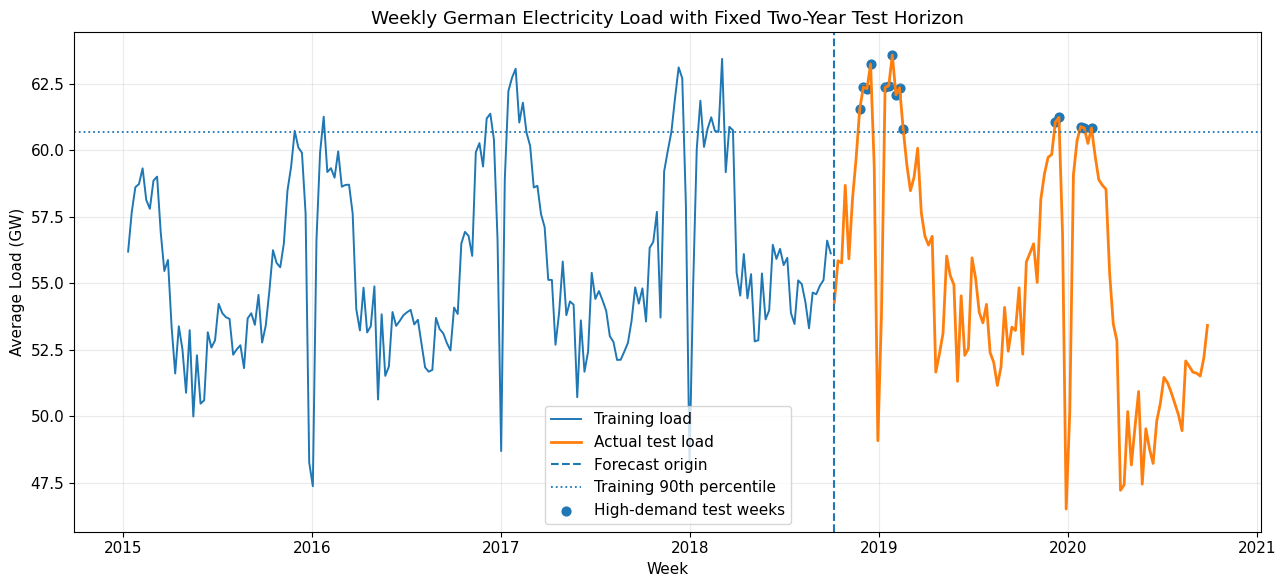

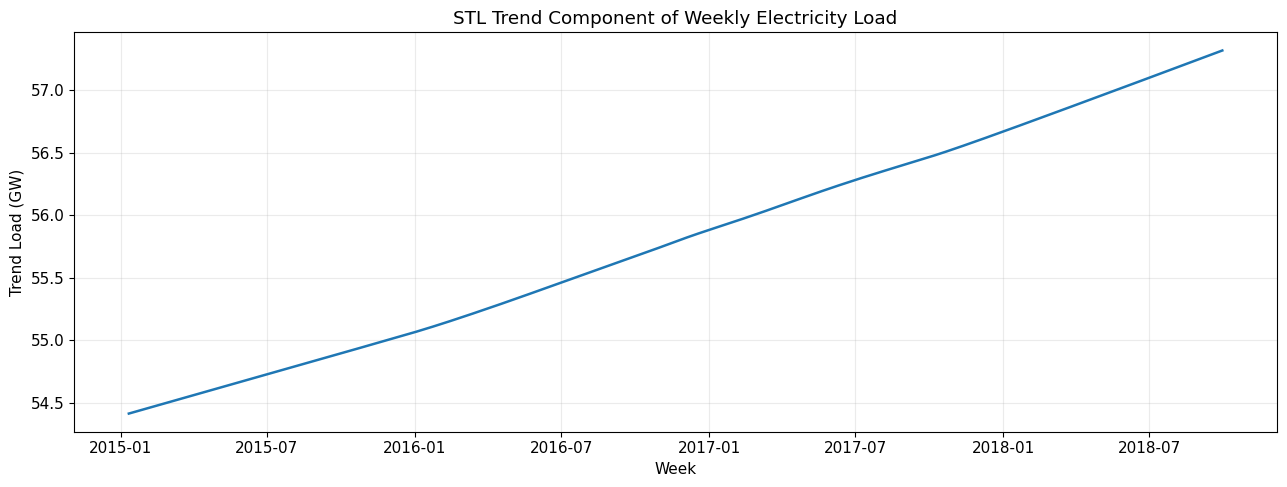

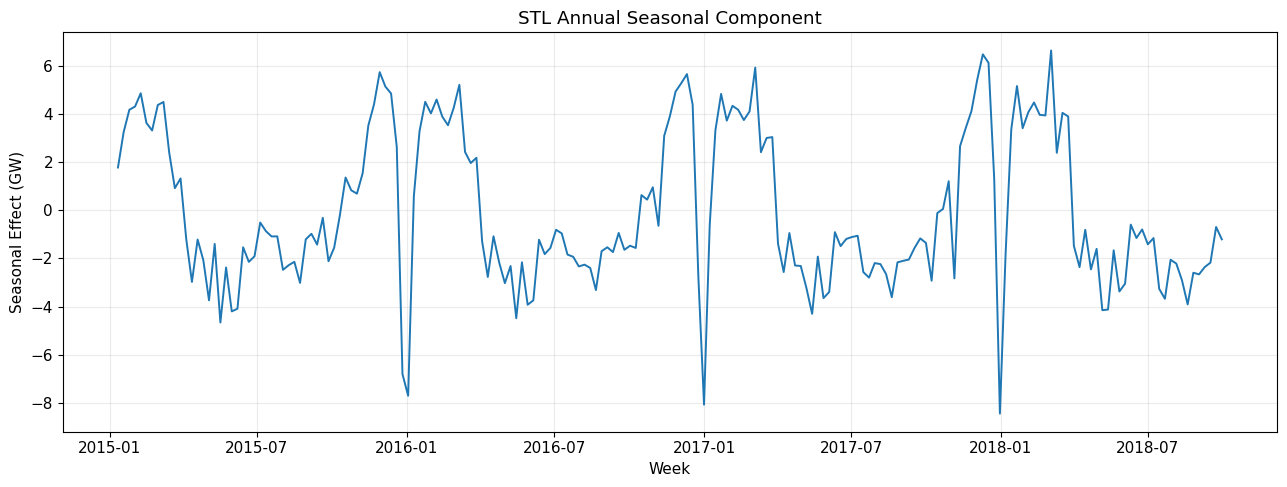

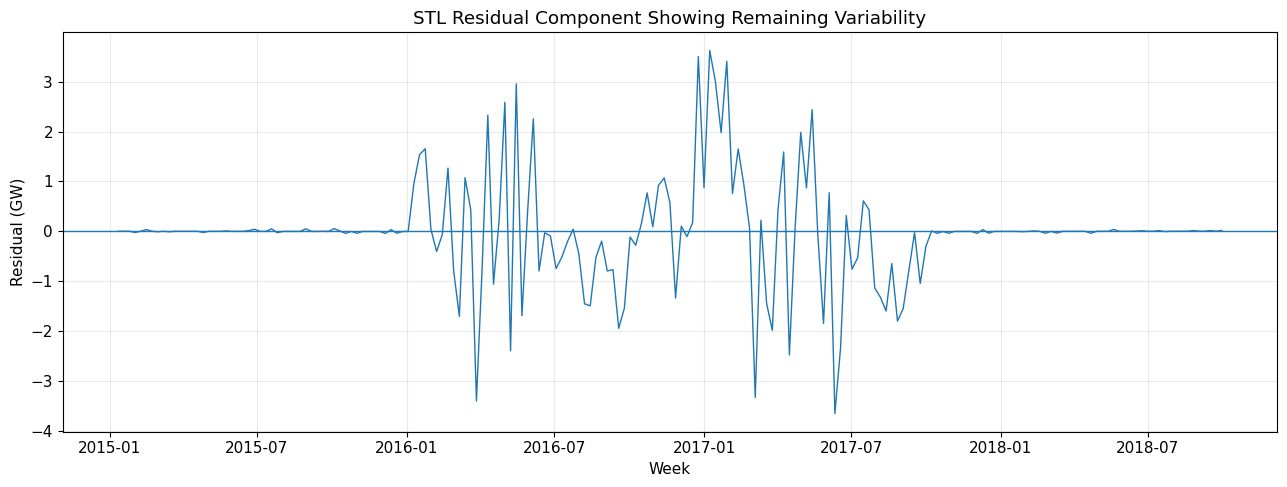

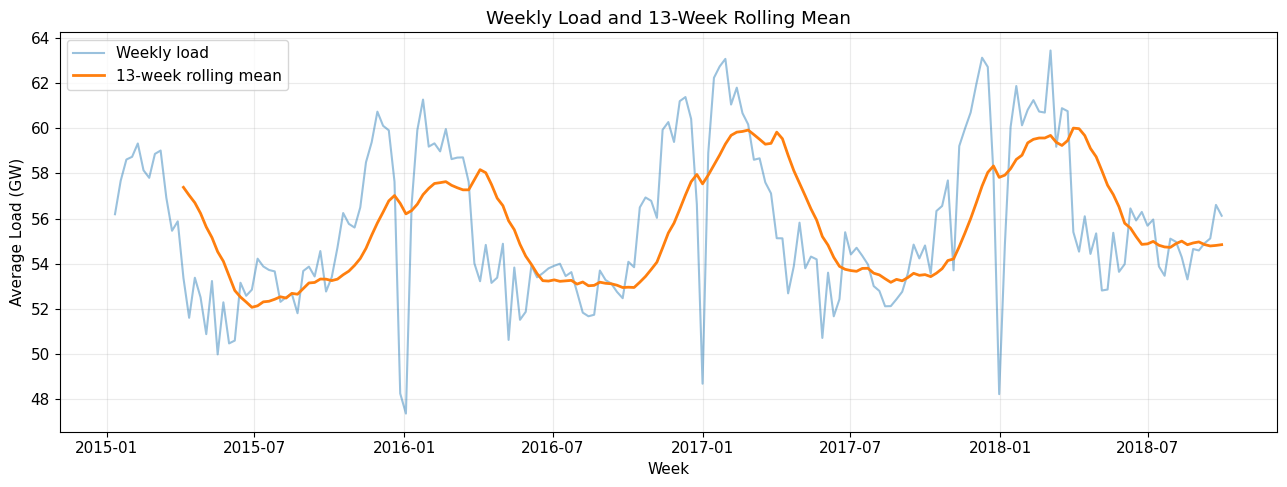

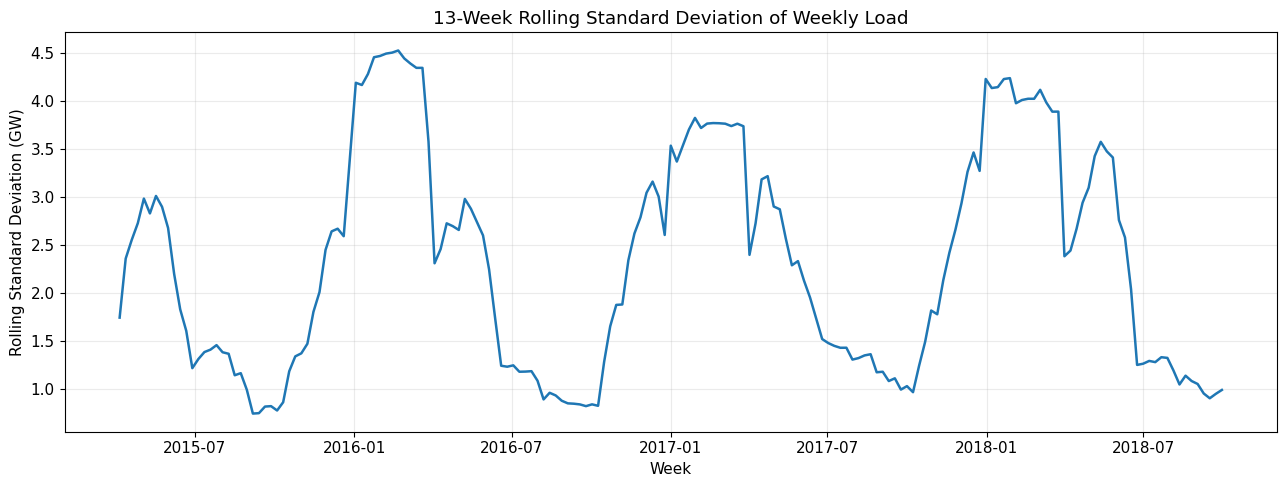

In [ ]:
# ============================================================
# CELL 4: EXPLORATORY ANALYSIS AND UNCERTAINTY PATTERNS
# ============================================================

# Define high-demand weeks using the training-period
# 90th percentile only.
high_demand_threshold = train.quantile(0.90)

high_demand_test_mask = (
    test >= high_demand_threshold
)


# ------------------------------------------------------------
# Plot 1: Weekly load with train-test split
# ------------------------------------------------------------

plt.figure(figsize=(13, 6))

plt.plot(
    train.index,
    train,
    label="Training load",
    linewidth=1.4
)

plt.plot(
    test.index,
    test,
    label="Actual test load",
    linewidth=2
)

plt.axvline(
    test.index[0],
    linestyle="--",
    linewidth=1.5,
    label="Forecast origin"
)

plt.axhline(
    high_demand_threshold,
    linestyle=":",
    linewidth=1.3,
    label="Training 90th percentile"
)

plt.scatter(
    test.index[high_demand_test_mask],
    test.loc[high_demand_test_mask],
    s=40,
    label="High-demand test weeks"
)

plt.title(
    "Weekly German Electricity Load with Fixed Two-Year Test Horizon"
)

plt.xlabel("Week")
plt.ylabel("Average Load (GW)")
plt.legend()
plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "weekly_load_train_test.png",
    dpi=300
)

plt.show()


# ------------------------------------------------------------
# STL decomposition using training data only
# ------------------------------------------------------------

stl_model = STL(
    train,
    period=SEASONAL_PERIOD,
    robust=True
)

stl_result = stl_model.fit()


# Plot 2: STL trend component
plt.figure(figsize=(13, 5))

plt.plot(
    stl_result.trend.index,
    stl_result.trend,
    linewidth=1.8
)

plt.title(
    "STL Trend Component of Weekly Electricity Load"
)

plt.xlabel("Week")
plt.ylabel("Trend Load (GW)")
plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "stl_trend.png",
    dpi=300
)

plt.show()


# Plot 3: STL seasonal component
plt.figure(figsize=(13, 5))

plt.plot(
    stl_result.seasonal.index,
    stl_result.seasonal,
    linewidth=1.4
)

plt.title(
    "STL Annual Seasonal Component"
)

plt.xlabel("Week")
plt.ylabel("Seasonal Effect (GW)")
plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "stl_seasonal.png",
    dpi=300
)

plt.show()


# Plot 4: STL residual component
plt.figure(figsize=(13, 5))

plt.plot(
    stl_result.resid.index,
    stl_result.resid,
    linewidth=1
)

plt.axhline(
    0,
    linewidth=1
)

plt.title(
    "STL Residual Component Showing Remaining Variability"
)

plt.xlabel("Week")
plt.ylabel("Residual (GW)")
plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "stl_residual.png",
    dpi=300
)

plt.show()


# ------------------------------------------------------------
# Rolling mean and rolling standard deviation
# ------------------------------------------------------------

rolling_window = 13

rolling_mean = train.rolling(
    rolling_window
).mean()

rolling_standard_deviation = train.rolling(
    rolling_window
).std()


# Plot 5: Rolling mean
plt.figure(figsize=(13, 5))

plt.plot(
    train.index,
    train,
    alpha=0.45,
    label="Weekly load"
)

plt.plot(
    rolling_mean.index,
    rolling_mean,
    linewidth=2,
    label="13-week rolling mean"
)

plt.title(
    "Weekly Load and 13-Week Rolling Mean"
)

plt.xlabel("Week")
plt.ylabel("Average Load (GW)")
plt.legend()
plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "rolling_mean.png",
    dpi=300
)

plt.show()


# Plot 6: Rolling standard deviation
plt.figure(figsize=(13, 5))

plt.plot(
    rolling_standard_deviation.index,
    rolling_standard_deviation,
    linewidth=1.8
)

plt.title(
    "13-Week Rolling Standard Deviation of Weekly Load"
)

plt.xlabel("Week")
plt.ylabel("Rolling Standard Deviation (GW)")
plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "rolling_standard_deviation.png",
    dpi=300
)

plt.show()

,Series,ADF statistic,ADF p-value,ADF lags,ADF observations,KPSS statistic,KPSS p-value,KPSS lags
0,Original weekly load,-5.0030,0.0,0,194,0.1499,0.1,8
1,First difference,-5.5708,0.0,7,186,0.0406,0.1,17
2,Seasonal difference at lag 52,-5.0395,0.0,3,139,0.0910,0.1,6
3,First and seasonal difference,-6.7279,0.0,10,131,0.0138,0.1,3


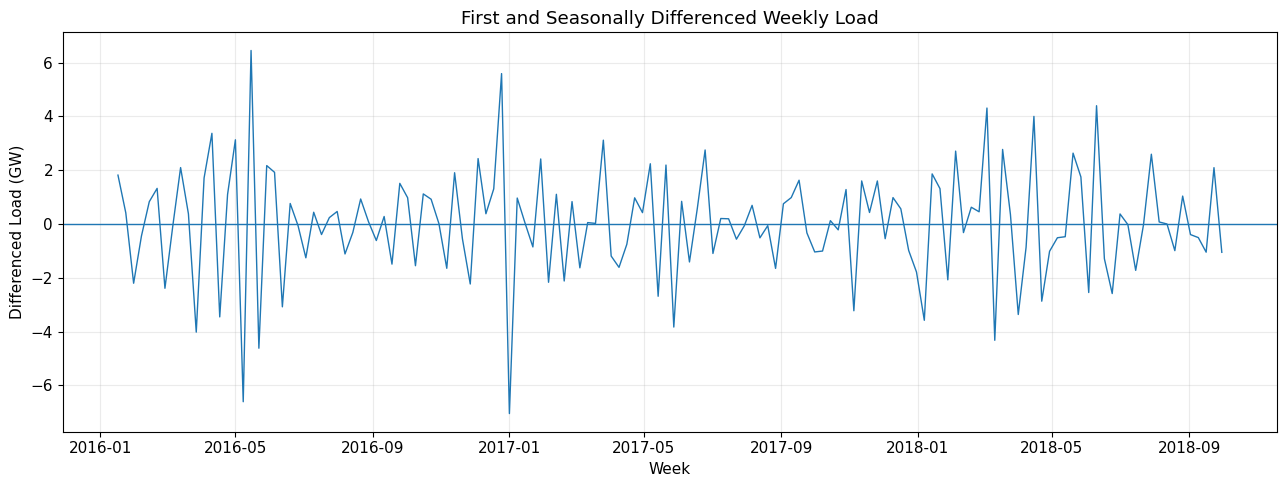

<Figure size 1200x500 with 0 Axes>

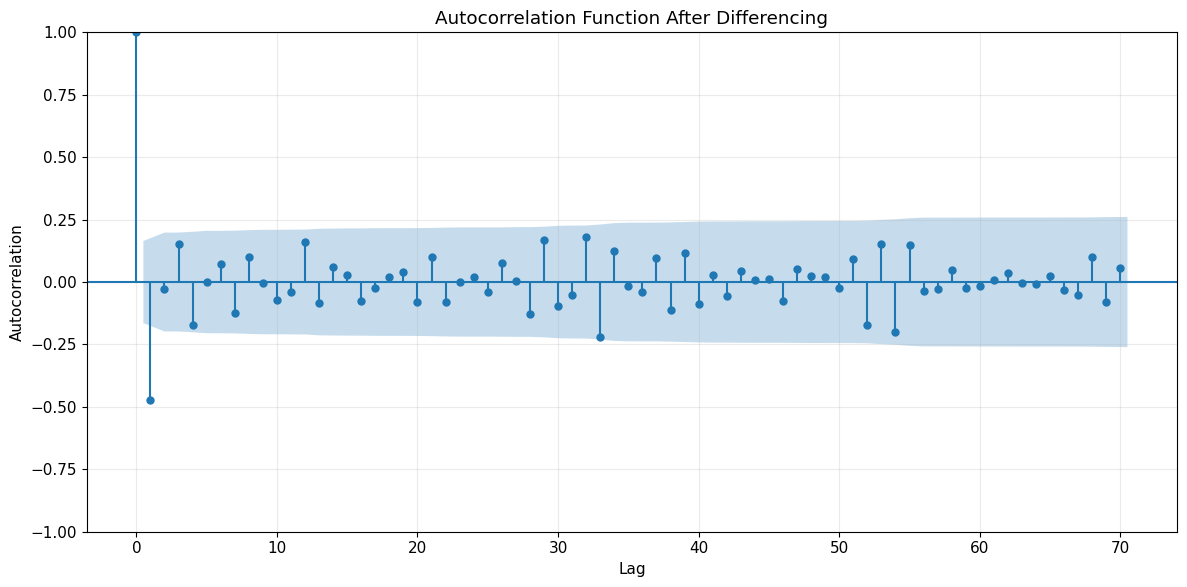

<Figure size 1200x500 with 0 Axes>

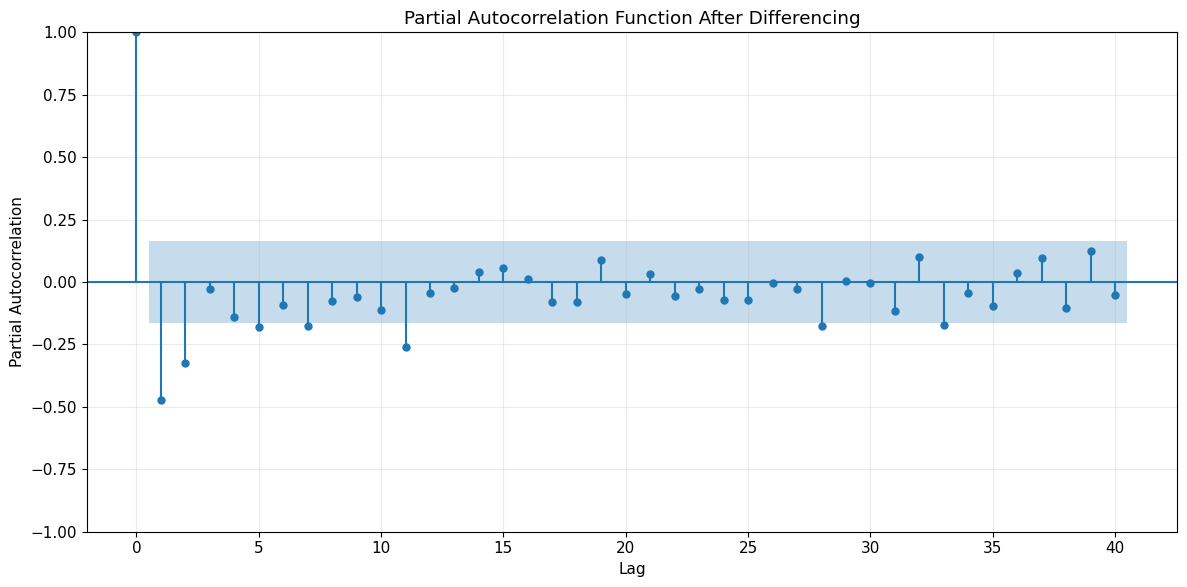

In [ ]:
# ============================================================
# CELL 5: STATIONARITY TESTS AND MODEL IDENTIFICATION
# ============================================================

def run_adf_test(series):
    """
    Run the Augmented Dickey-Fuller test.

    Null hypothesis:
        The series contains a unit root and is non-stationary.
    """
    clean_series = pd.Series(
        series
    ).dropna().astype(float)

    result = adfuller(
        clean_series,
        autolag="AIC"
    )

    return {
        "ADF statistic": result[0],
        "ADF p-value": result[1],
        "ADF lags": result[2],
        "ADF observations": result[3]
    }


def run_kpss_test(series):
    """
    Run the KPSS test.

    Null hypothesis:
        The series is level-stationary.
    """
    clean_series = pd.Series(
        series
    ).dropna().astype(float)

    result = kpss(
        clean_series,
        regression="c",
        nlags="auto"
    )

    return {
        "KPSS statistic": result[0],
        "KPSS p-value": result[1],
        "KPSS lags": result[2]
    }


# Create alternative differenced versions.
stationarity_series = {
    "Original weekly load": train,
    "First difference": train.diff(),
    "Seasonal difference at lag 52": (
        train.diff(SEASONAL_PERIOD)
    ),
    "First and seasonal difference": (
        train
        .diff()
        .diff(SEASONAL_PERIOD)
    )
}


stationarity_results = []

for series_name, series_values in stationarity_series.items():

    result_row = {
        "Series": series_name
    }

    result_row.update(
        run_adf_test(series_values)
    )

    result_row.update(
        run_kpss_test(series_values)
    )

    stationarity_results.append(
        result_row
    )


stationarity_table = pd.DataFrame(
    stationarity_results
)

display(
    stationarity_table.round(4)
)

stationarity_table.to_csv(
    RESULTS_DIR / "stationarity_tests.csv",
    index=False
)


# Use the combined differenced series for ACF and PACF.
identified_series = (
    train
    .diff()
    .diff(SEASONAL_PERIOD)
    .dropna()
)


# ------------------------------------------------------------
# Plot 1: Differenced series
# ------------------------------------------------------------

plt.figure(figsize=(13, 5))

plt.plot(
    identified_series.index,
    identified_series,
    linewidth=1
)

plt.axhline(
    0,
    linewidth=1
)

plt.title(
    "First and Seasonally Differenced Weekly Load"
)

plt.xlabel("Week")
plt.ylabel("Differenced Load (GW)")
plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "differenced_weekly_load.png",
    dpi=300
)

plt.show()


# ------------------------------------------------------------
# Plot 2: ACF
# ------------------------------------------------------------

plt.figure(figsize=(12, 5))

plot_acf(
    identified_series,
    lags=min(
        70,
        len(identified_series) // 2 - 1
    )
)

plt.title(
    "Autocorrelation Function After Differencing"
)

plt.xlabel("Lag")
plt.ylabel("Autocorrelation")
plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "acf_after_differencing.png",
    dpi=300
)

plt.show()


# ------------------------------------------------------------
# Plot 3: PACF
# ------------------------------------------------------------

plt.figure(figsize=(12, 5))

plot_pacf(
    identified_series,
    lags=min(
        40,
        len(identified_series) // 2 - 1
    ),
    method="ywm"
)

plt.title(
    "Partial Autocorrelation Function After Differencing"
)

plt.xlabel("Lag")
plt.ylabel("Partial Autocorrelation")
plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "pacf_after_differencing.png",
    dpi=300
)

plt.show()

,Model,MAE,RMSE,sMAPE (%),MASE,Bias (forecast - actual)
0,Mean,3.790,4.402,6.874,2.805,0.561
1,Naive,3.858,4.476,6.995,2.856,0.985
2,Seasonal naive,2.288,2.988,4.207,1.694,1.748
3,Drift,3.851,4.466,6.982,2.850,0.966


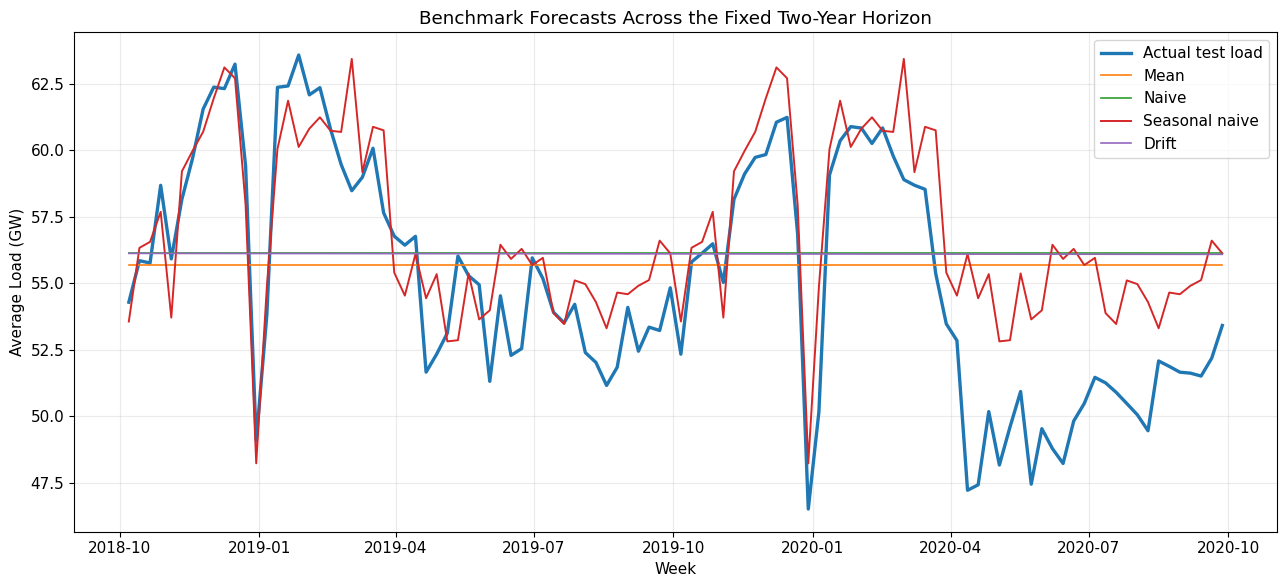

In [ ]:
# ============================================================
# CELL 6: FIXED-ORIGIN BENCHMARK FORECASTS
# ============================================================

forecast_horizon = len(test)


# -----------------------------
# Mean forecast
# -----------------------------

mean_forecast = pd.Series(
    train.mean(),
    index=test.index,
    name="Mean"
)


# -----------------------------
# Naive forecast
# -----------------------------

naive_forecast = pd.Series(
    train.iloc[-1],
    index=test.index,
    name="Naive"
)


# -----------------------------
# Seasonal-naive forecast
# -----------------------------

# Repeat the final observed 52-week training cycle.
# Actual test observations are not inserted into later forecasts.
last_training_season = train.iloc[
    -SEASONAL_PERIOD:
].to_numpy()

seasonal_naive_values = np.resize(
    last_training_season,
    forecast_horizon
)

seasonal_naive_forecast = pd.Series(
    seasonal_naive_values,
    index=test.index,
    name="Seasonal naive"
)


# -----------------------------
# Drift forecast
# -----------------------------

drift_slope = (
    train.iloc[-1] - train.iloc[0]
) / (
    len(train) - 1
)

drift_values = (
    train.iloc[-1]
    + drift_slope
    * np.arange(
        1,
        forecast_horizon + 1
    )
)

drift_forecast = pd.Series(
    drift_values,
    index=test.index,
    name="Drift"
)


# Store forecasts so advanced models can be added later.
point_forecasts = {
    "Mean": mean_forecast,
    "Naive": naive_forecast,
    "Seasonal naive": seasonal_naive_forecast,
    "Drift": drift_forecast
}


# Store evaluation results in a common list.
point_metric_rows = []

for model_name, model_forecast in point_forecasts.items():

    point_metric_rows.append(
        evaluate_point_forecast(
            model_name=model_name,
            actual=test,
            forecast=model_forecast,
            training_series=train
        )
    )


benchmark_metrics = pd.DataFrame(
    point_metric_rows
)

display(
    benchmark_metrics.round(3)
)


# ------------------------------------------------------------
# Benchmark forecast plot
# ------------------------------------------------------------

plt.figure(figsize=(13, 6))

plt.plot(
    test.index,
    test,
    label="Actual test load",
    linewidth=2.4
)

plt.plot(
    mean_forecast.index,
    mean_forecast,
    label="Mean",
    linewidth=1.2
)

plt.plot(
    naive_forecast.index,
    naive_forecast,
    label="Naive",
    linewidth=1.2
)

plt.plot(
    seasonal_naive_forecast.index,
    seasonal_naive_forecast,
    label="Seasonal naive",
    linewidth=1.4
)

plt.plot(
    drift_forecast.index,
    drift_forecast,
    label="Drift",
    linewidth=1.2
)

plt.title(
    "Benchmark Forecasts Across the Fixed Two-Year Horizon"
)

plt.xlabel("Week")
plt.ylabel("Average Load (GW)")
plt.legend()
plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "benchmark_forecasts.png",
    dpi=300
)

plt.show()

In [ ]:
# ============================================================
# CELL 7: SARIMA AIC PARAMETER SEARCH
# ============================================================

# The assignment explicitly requires every combination of:
# p = 0 to 6
# d = 0 to 2
# q = 0 to 6
#
# Stage 1 searches all 147 required non-seasonal combinations
# while using an annual weekly seasonal structure.
#
# Stage 2 keeps the best p, d and q and searches alternative
# P, D and Q combinations.

SARIMA_STAGE1_FILE = (
    RESULTS_DIR / "sarima_stage1_search.csv"
)

SARIMA_STAGE2_FILE = (
    RESULTS_DIR / "sarima_stage2_search.csv"
)


def fit_sarima_model(
    training_series,
    order,
    seasonal_order
):
    """
    Fit one SARIMA candidate.

    A constant is included only when no regular or seasonal
    differencing is used.
    """
    regular_differencing = order[1]
    seasonal_differencing = seasonal_order[1]

    trend = (
        "c"
        if regular_differencing == 0
        and seasonal_differencing == 0
        else "n"
    )

    model = SARIMAX(
        training_series,
        order=order,
        seasonal_order=seasonal_order,
        trend=trend,
        enforce_stationarity=False,
        enforce_invertibility=False
    )

    fitted_model = model.fit(
        disp=False,
        maxiter=150
    )

    return fitted_model


def run_stage_one_search(
    training_series,
    output_file
):
    """
    Search every required p, d and q combination.

    The initial seasonal structure is fixed at:
        SARIMA (p,d,q)(1,1,1,52)
    """
    required_orders = list(
        product(
            range(7),
            range(3),
            range(7)
        )
    )

    seasonal_order = (
        1,
        1,
        1,
        SEASONAL_PERIOD
    )

    completed_results = []

    for candidate_number, order in enumerate(
        required_orders,
        start=1
    ):

        start_time = time.time()

        try:
            fitted_model = fit_sarima_model(
                training_series,
                order,
                seasonal_order
            )

            result = {
                "order": str(order),
                "seasonal_order": str(
                    seasonal_order
                ),
                "AIC": fitted_model.aic,
                "BIC": fitted_model.bic,
                "Converged": bool(
                    fitted_model
                    .mle_retvals
                    .get("converged", False)
                ),
                "Seconds": (
                    time.time() - start_time
                ),
                "Error": ""
            }

        except Exception as error:

            result = {
                "order": str(order),
                "seasonal_order": str(
                    seasonal_order
                ),
                "AIC": np.nan,
                "BIC": np.nan,
                "Converged": False,
                "Seconds": (
                    time.time() - start_time
                ),
                "Error": str(error)[:200]
            }

        completed_results.append(
            result
        )

        # Save continuously so that completed results are not
        # lost if the notebook stops.
        pd.DataFrame(
            completed_results
        ).to_csv(
            output_file,
            index=False
        )

        if candidate_number % 10 == 0:
            print(
                f"Completed "
                f"{candidate_number}/"
                f"{len(required_orders)} "
                f"required p,d,q combinations"
            )

    return pd.DataFrame(
        completed_results
    )


def run_stage_two_search(
    training_series,
    best_nonseasonal_order,
    output_file
):
    """
    Search seasonal P, D and Q values of 0 or 1 while keeping
    the best non-seasonal order from Stage 1.
    """
    seasonal_candidates = [
        (
            P,
            D,
            Q,
            SEASONAL_PERIOD
        )
        for P, D, Q in product(
            range(2),
            range(2),
            range(2)
        )
    ]

    stage_two_results = []

    for seasonal_order in seasonal_candidates:

        start_time = time.time()

        try:
            fitted_model = fit_sarima_model(
                training_series,
                best_nonseasonal_order,
                seasonal_order
            )

            result = {
                "order": str(
                    best_nonseasonal_order
                ),
                "seasonal_order": str(
                    seasonal_order
                ),
                "AIC": fitted_model.aic,
                "BIC": fitted_model.bic,
                "Converged": bool(
                    fitted_model
                    .mle_retvals
                    .get("converged", False)
                ),
                "Seconds": (
                    time.time() - start_time
                ),
                "Error": ""
            }

        except Exception as error:

            result = {
                "order": str(
                    best_nonseasonal_order
                ),
                "seasonal_order": str(
                    seasonal_order
                ),
                "AIC": np.nan,
                "BIC": np.nan,
                "Converged": False,
                "Seconds": (
                    time.time() - start_time
                ),
                "Error": str(error)[:200]
            }

        stage_two_results.append(
            result
        )

    stage_two_results = pd.DataFrame(
        stage_two_results
    )

    stage_two_results.to_csv(
        output_file,
        index=False
    )

    return stage_two_results


# -----------------------------
# Run or load Stage 1
# -----------------------------

if RUN_SARIMA_SEARCH:

    stage_one_results = run_stage_one_search(
        training_series=train,
        output_file=SARIMA_STAGE1_FILE
    )

else:

    if not SARIMA_STAGE1_FILE.exists():
        raise FileNotFoundError(
            "No saved SARIMA Stage 1 results were found."
        )

    stage_one_results = pd.read_csv(
        SARIMA_STAGE1_FILE
    )


successful_stage_one = (
    stage_one_results
    .dropna(subset=["AIC"])
    .sort_values("AIC")
    .reset_index(drop=True)
)

if successful_stage_one.empty:
    raise RuntimeError(
        "All Stage 1 SARIMA candidates failed."
    )


best_stage_one_order = ast.literal_eval(
    successful_stage_one.iloc[0]["order"]
)


print(
    "Best p,d,q from required search:",
    best_stage_one_order
)

display(
    successful_stage_one.head(10).round(3)
)


# -----------------------------
# Run seasonal Stage 2
# -----------------------------

if RUN_SARIMA_SEARCH:

    stage_two_results = run_stage_two_search(
        training_series=train,
        best_nonseasonal_order=best_stage_one_order,
        output_file=SARIMA_STAGE2_FILE
    )

else:

    if not SARIMA_STAGE2_FILE.exists():
        raise FileNotFoundError(
            "No saved SARIMA Stage 2 results were found."
        )

    stage_two_results = pd.read_csv(
        SARIMA_STAGE2_FILE
    )


successful_stage_two = (
    stage_two_results
    .dropna(subset=["AIC"])
    .sort_values("AIC")
    .reset_index(drop=True)
)

if successful_stage_two.empty:
    raise RuntimeError(
        "All Stage 2 seasonal candidates failed."
    )


best_sarima_order = ast.literal_eval(
    successful_stage_two.iloc[0]["order"]
)

best_sarima_seasonal_order = ast.literal_eval(
    successful_stage_two.iloc[0][
        "seasonal_order"
    ]
)


print(
    "Selected SARIMA order:",
    best_sarima_order
)

print(
    "Selected seasonal order:",
    best_sarima_seasonal_order
)

print(
    "Lowest training AIC:",
    round(
        successful_stage_two.iloc[0]["AIC"],
        3
    )
)

display(
    successful_stage_two.round(3)
)

Completed 10/147 required p,d,q combinations
Completed 20/147 required p,d,q combinations
Completed 30/147 required p,d,q combinations
Completed 40/147 required p,d,q combinations
Completed 50/147 required p,d,q combinations
Completed 60/147 required p,d,q combinations
Completed 70/147 required p,d,q combinations
Completed 80/147 required p,d,q combinations
Completed 90/147 required p,d,q combinations
Completed 100/147 required p,d,q combinations
Completed 110/147 required p,d,q combinations
Completed 120/147 required p,d,q combinations
Completed 130/147 required p,d,q combinations
Completed 140/147 required p,d,q combinations
Best p,d,q from required search: (1, 1, 6)


,order,seasonal_order,AIC,BIC,Converged,Seconds,Error
0,"(1, 1, 6)","(1, 1, 1, 52)",297.219,321.408,True,57.410,
1,"(4, 1, 6)","(1, 1, 1, 52)",297.841,329.286,False,145.258,
2,"(0, 1, 6)","(1, 1, 1, 52)",298.642,320.412,True,42.907,
3,"(3, 1, 6)","(1, 1, 1, 52)",298.749,327.775,True,69.945,
4,"(5, 1, 6)","(1, 1, 1, 52)",299.713,333.576,True,142.596,
5,"(2, 0, 6)","(1, 1, 1, 52)",299.765,326.504,True,83.915,
6,"(5, 0, 6)","(1, 1, 1, 52)",300.350,334.381,False,163.829,
7,"(1, 0, 6)","(1, 1, 1, 52)",300.953,325.261,True,52.573,
8,"(6, 2, 6)","(1, 1, 1, 52)",300.962,337.063,False,172.195,
9,"(4, 0, 6)","(1, 1, 1, 52)",301.668,333.268,False,145.109,


Selected SARIMA order: (1, 1, 6)
Selected seasonal order: (1, 1, 1, 52)
Lowest training AIC: 297.219


,order,seasonal_order,AIC,BIC,Converged,Seconds,Error
0,"(1, 1, 6)","(1, 1, 1, 52)",297.219,321.408,True,57.238,
1,"(1, 1, 6)","(0, 1, 1, 52)",299.120,320.889,True,22.267,
2,"(1, 1, 6)","(1, 1, 0, 52)",322.365,344.763,True,37.194,
3,"(1, 1, 6)","(0, 1, 0, 52)",525.349,548.591,True,4.538,
4,"(1, 1, 6)","(1, 0, 0, 52)",540.151,566.690,True,3.050,
5,"(1, 1, 6)","(0, 0, 0, 52)",831.691,857.540,True,0.186,
6,"(1, 1, 6)","(0, 0, 1, 52)",4982.158,5008.305,False,5.097,
7,"(1, 1, 6)","(1, 0, 1, 52)",5044.265,5073.317,False,5.646,


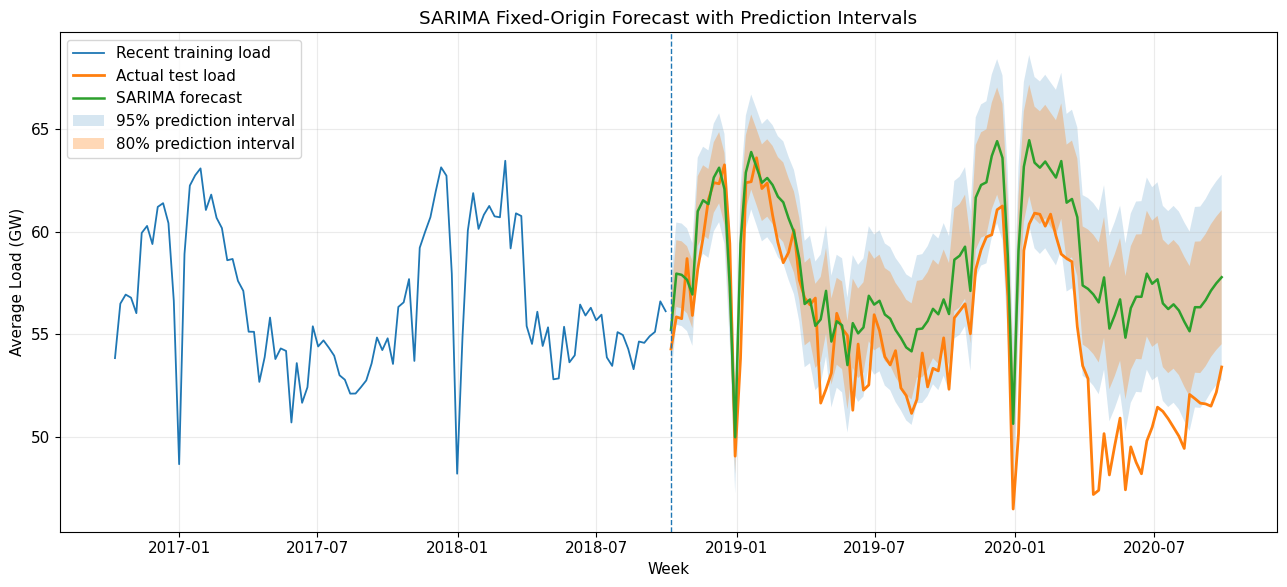

,Model,Residual mean,Residual standard deviation,Residual skewness,Residual kurtosis,Ljung-Box p-value lag 10,Ljung-Box p-value lag 20,Ljung-Box p-value lag 52
0,SARIMA,-0.1331,1.2816,0.0021,0.1533,0.9879,0.5565,0.7471


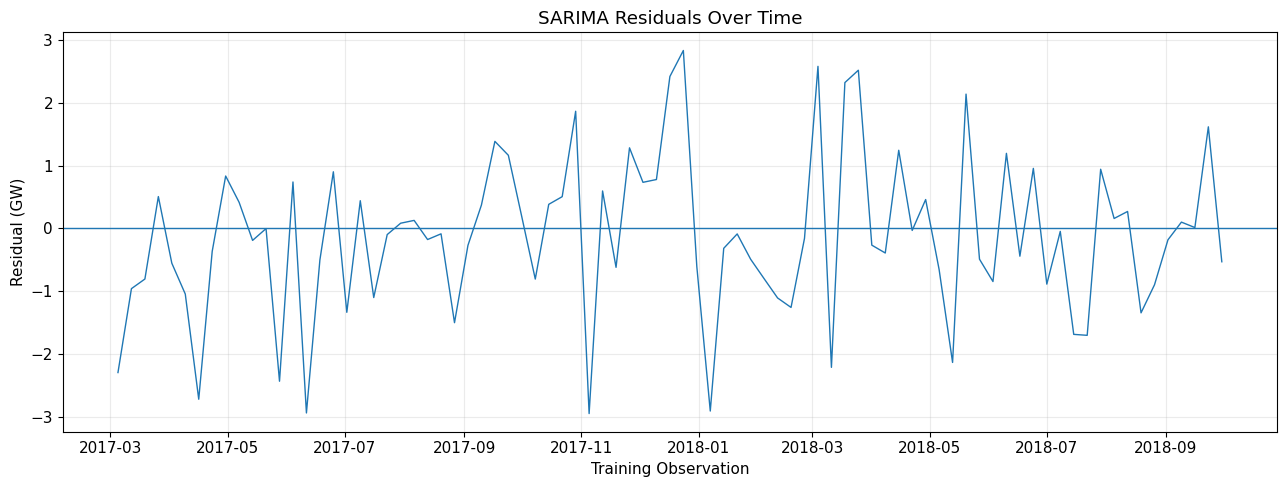

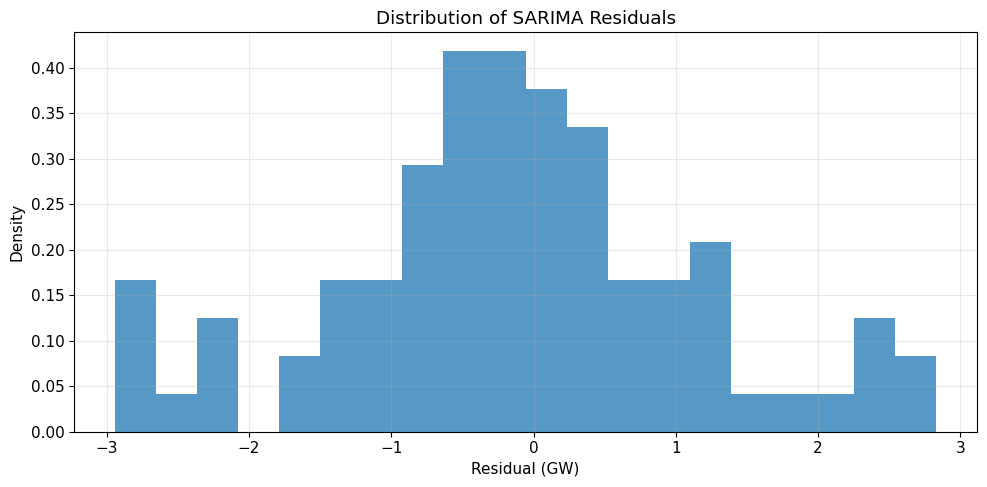

<Figure size 1200x500 with 0 Axes>

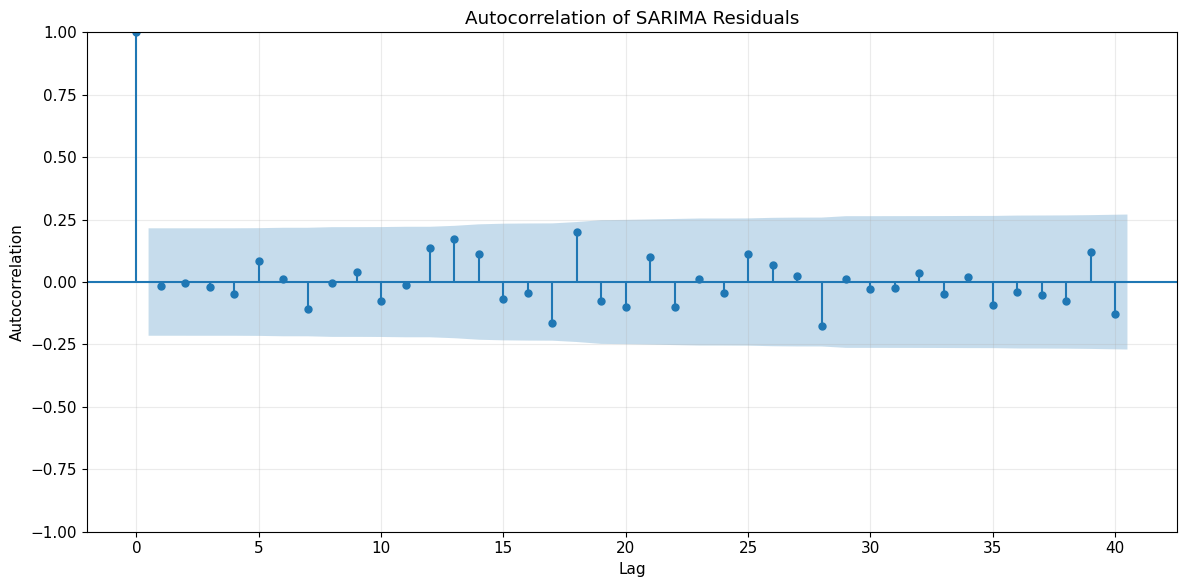

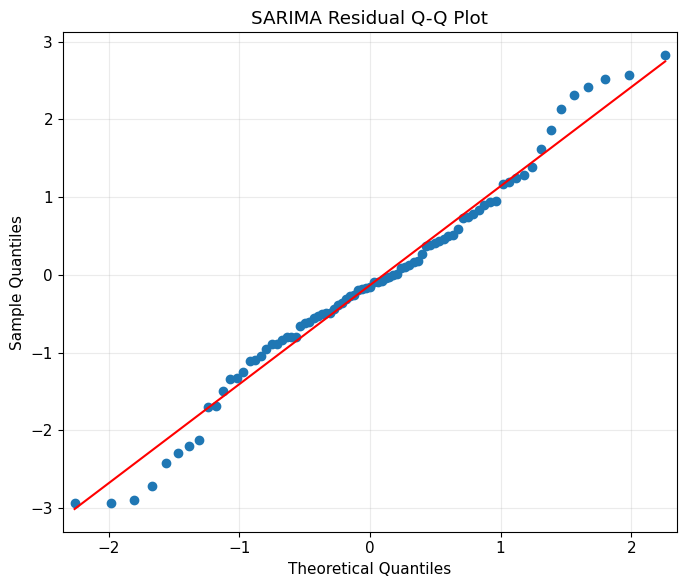

In [ ]:
# ============================================================
# CELL 8: FINAL SARIMA FORECAST AND DIAGNOSTICS
# ============================================================

# Fit the selected model on the complete weekly training set.
sarima_fit = fit_sarima_model(
    training_series=train,
    order=best_sarima_order,
    seasonal_order=best_sarima_seasonal_order
)


# Produce a fixed-origin 104-week forecast.
sarima_forecast_object = (
    sarima_fit.get_forecast(
        steps=len(test)
    )
)


sarima_forecast = pd.Series(
    sarima_forecast_object
    .predicted_mean
    .to_numpy(),
    index=test.index,
    name="SARIMA"
)


# -----------------------------
# Extract 80% interval
# -----------------------------

sarima_80_raw = (
    sarima_forecast_object
    .conf_int(alpha=0.20)
)

sarima_interval_80 = pd.DataFrame(
    {
        "lower": (
            sarima_80_raw
            .iloc[:, 0]
            .to_numpy()
        ),
        "upper": (
            sarima_80_raw
            .iloc[:, 1]
            .to_numpy()
        )
    },
    index=test.index
)


# -----------------------------
# Extract 95% interval
# -----------------------------

sarima_95_raw = (
    sarima_forecast_object
    .conf_int(alpha=0.05)
)

sarima_interval_95 = pd.DataFrame(
    {
        "lower": (
            sarima_95_raw
            .iloc[:, 0]
            .to_numpy()
        ),
        "upper": (
            sarima_95_raw
            .iloc[:, 1]
            .to_numpy()
        )
    },
    index=test.index
)


# Add SARIMA to the common point-forecast comparison.
point_forecasts["SARIMA"] = sarima_forecast

point_metric_rows.append(
    evaluate_point_forecast(
        model_name="SARIMA",
        actual=test,
        forecast=sarima_forecast,
        training_series=train
    )
)


# -----------------------------
# SARIMA interval plot
# -----------------------------

plt.figure(figsize=(13, 6))

plt.plot(
    train.iloc[-104:].index,
    train.iloc[-104:],
    label="Recent training load",
    linewidth=1.3
)

plt.plot(
    test.index,
    test,
    label="Actual test load",
    linewidth=2
)

plt.plot(
    sarima_forecast.index,
    sarima_forecast,
    label="SARIMA forecast",
    linewidth=1.8
)

plt.fill_between(
    sarima_interval_95.index,
    sarima_interval_95["lower"],
    sarima_interval_95["upper"],
    alpha=0.18,
    label="95% prediction interval"
)

plt.fill_between(
    sarima_interval_80.index,
    sarima_interval_80["lower"],
    sarima_interval_80["upper"],
    alpha=0.30,
    label="80% prediction interval"
)

plt.axvline(
    test.index[0],
    linestyle="--",
    linewidth=1
)

plt.title(
    "SARIMA Fixed-Origin Forecast with Prediction Intervals"
)

plt.xlabel("Week")
plt.ylabel("Average Load (GW)")
plt.legend()
plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "sarima_prediction_intervals.png",
    dpi=300
)

plt.show()


# -----------------------------
# Residual diagnostics
# -----------------------------

sarima_diagnostic_row, sarima_residuals = (
    create_residual_diagnostics(
        "SARIMA",
        sarima_fit
    )
)

display(
    pd.DataFrame(
        [sarima_diagnostic_row]
    ).round(4)
)


# Plot: residuals over time
plt.figure(figsize=(13, 5))

plt.plot(
    sarima_residuals.index,
    sarima_residuals,
    linewidth=1
)

plt.axhline(
    0,
    linewidth=1
)

plt.title(
    "SARIMA Residuals Over Time"
)

plt.xlabel("Training Observation")
plt.ylabel("Residual (GW)")
plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "sarima_residual_time_plot.png",
    dpi=300
)

plt.show()


# Plot: residual histogram
plt.figure(figsize=(10, 5))

plt.hist(
    sarima_residuals,
    bins=20,
    density=True,
    alpha=0.75
)

plt.title(
    "Distribution of SARIMA Residuals"
)

plt.xlabel("Residual (GW)")
plt.ylabel("Density")
plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "sarima_residual_histogram.png",
    dpi=300
)

plt.show()


# Plot: residual ACF
plt.figure(figsize=(12, 5))

plot_acf(
    sarima_residuals,
    lags=min(
        60,
        len(sarima_residuals) // 2 - 1
    )
)

plt.title(
    "Autocorrelation of SARIMA Residuals"
)

plt.xlabel("Lag")
plt.ylabel("Autocorrelation")
plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "sarima_residual_acf.png",
    dpi=300
)

plt.show()


# Plot: residual Q-Q plot
plt.figure(figsize=(7, 6))

qqplot(
    sarima_residuals,
    line="s",
    ax=plt.gca()
)

plt.title(
    "SARIMA Residual Q-Q Plot"
)

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "sarima_residual_qq.png",
    dpi=300
)

plt.show()

,Model,Training AIC
0,SARIMA,297.219
1,SARIMAX temperature,285.912
2,SARIMAX calendar,260.111
3,SARIMAX full,249.786


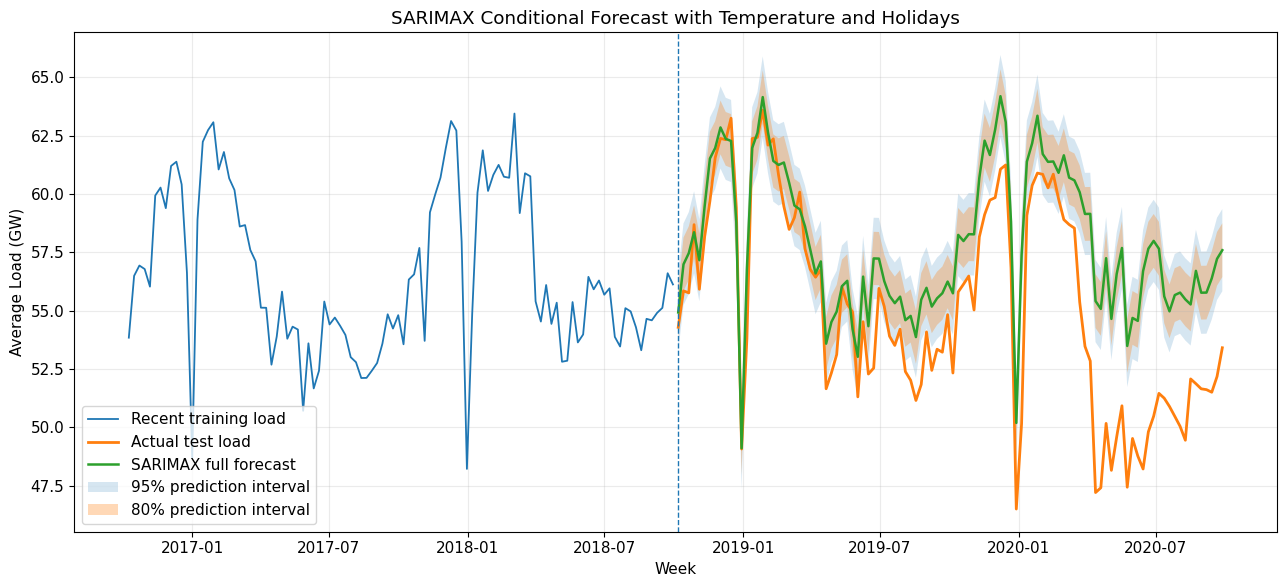

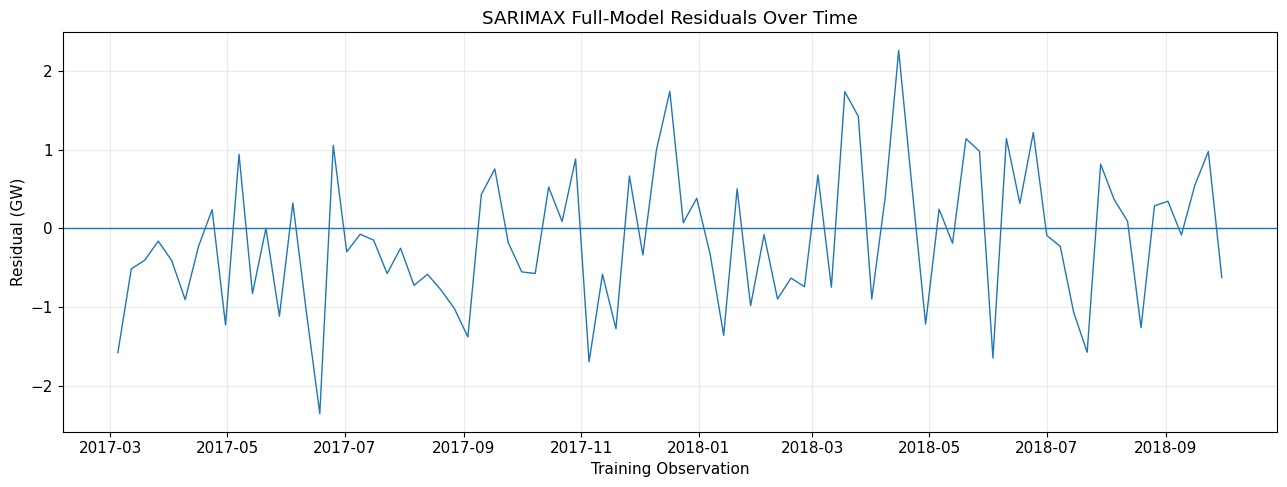

<Figure size 1200x500 with 0 Axes>

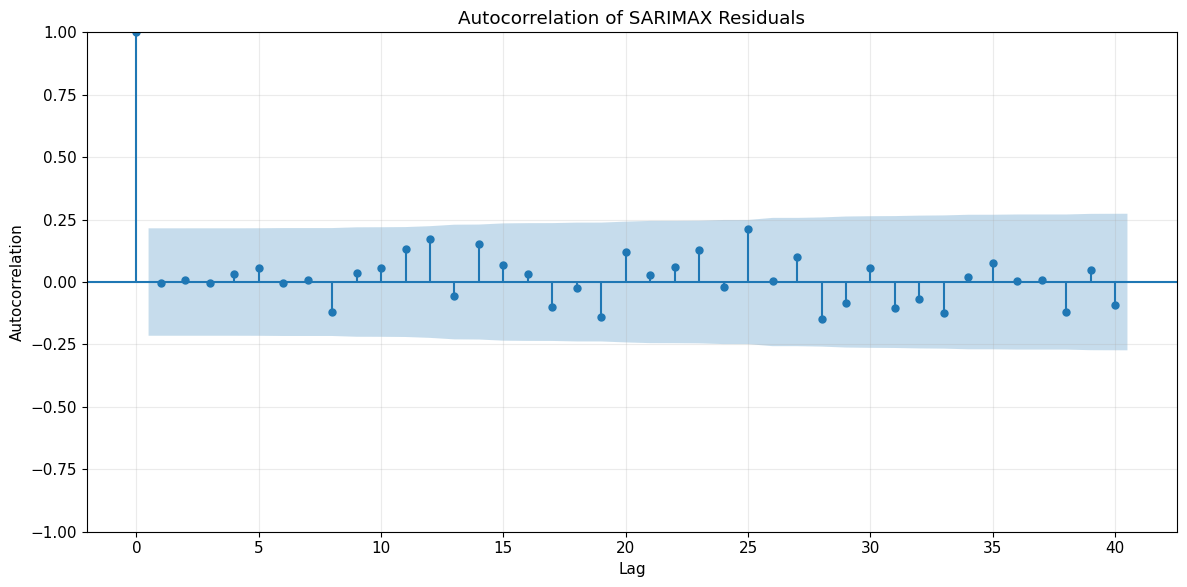

In [ ]:
# ============================================================
# CELL 9: SARIMAX WITH TEMPERATURE AND HOLIDAY VARIABLES
# ============================================================

# The same SARIMA order is retained so that the contribution
# of external information can be evaluated more clearly.

temperature_exog_columns = [
    "temperature_mean",
    "heating_degree",
    "cooling_degree"
]

calendar_exog_columns = [
    "holiday_count",
    "christmas_new_year"
]

full_exog_columns = (
    temperature_exog_columns
    + calendar_exog_columns
)


def fit_sarimax_variant(
    model_name,
    exogenous_columns
):
    """
    Fit one SARIMAX variant using training-only scaling.

    Observed test-period temperature is supplied to the model.
    The resulting forecast is therefore conditional rather than
    a fully operational forecast.
    """
    X_train = weekly_data.loc[
        train.index,
        exogenous_columns
    ].copy()

    X_test = weekly_data.loc[
        test.index,
        exogenous_columns
    ].copy()

    scaler = StandardScaler()

    X_train_scaled = pd.DataFrame(
        scaler.fit_transform(X_train),
        index=X_train.index,
        columns=X_train.columns
    )

    X_test_scaled = pd.DataFrame(
        scaler.transform(X_test),
        index=X_test.index,
        columns=X_test.columns
    )

    regular_d = best_sarima_order[1]
    seasonal_D = best_sarima_seasonal_order[1]

    trend = (
        "c"
        if regular_d == 0
        and seasonal_D == 0
        else "n"
    )

    model = SARIMAX(
        train,
        exog=X_train_scaled,
        order=best_sarima_order,
        seasonal_order=(
            best_sarima_seasonal_order
        ),
        trend=trend,
        enforce_stationarity=False,
        enforce_invertibility=False
    )

    fitted_model = model.fit(
        disp=False,
        maxiter=200
    )

    forecast_object = (
        fitted_model.get_forecast(
            steps=len(test),
            exog=X_test_scaled
        )
    )

    point_forecast = pd.Series(
        forecast_object
        .predicted_mean
        .to_numpy(),
        index=test.index,
        name=model_name
    )

    interval_80_raw = (
        forecast_object
        .conf_int(alpha=0.20)
    )

    interval_95_raw = (
        forecast_object
        .conf_int(alpha=0.05)
    )

    interval_80 = pd.DataFrame(
        {
            "lower": (
                interval_80_raw
                .iloc[:, 0]
                .to_numpy()
            ),
            "upper": (
                interval_80_raw
                .iloc[:, 1]
                .to_numpy()
            )
        },
        index=test.index
    )

    interval_95 = pd.DataFrame(
        {
            "lower": (
                interval_95_raw
                .iloc[:, 0]
                .to_numpy()
            ),
            "upper": (
                interval_95_raw
                .iloc[:, 1]
                .to_numpy()
            )
        },
        index=test.index
    )

    return {
        "name": model_name,
        "fit": fitted_model,
        "forecast": point_forecast,
        "interval_80": interval_80,
        "interval_95": interval_95,
        "AIC": fitted_model.aic
    }


# -----------------------------
# Fit three explanatory variants
# -----------------------------

sarimax_temperature = fit_sarimax_variant(
    model_name="SARIMAX temperature",
    exogenous_columns=temperature_exog_columns
)

sarimax_calendar = fit_sarimax_variant(
    model_name="SARIMAX calendar",
    exogenous_columns=calendar_exog_columns
)

sarimax_full = fit_sarimax_variant(
    model_name="SARIMAX full",
    exogenous_columns=full_exog_columns
)


sarimax_variants = {
    "SARIMAX temperature": (
        sarimax_temperature
    ),
    "SARIMAX calendar": (
        sarimax_calendar
    ),
    "SARIMAX full": (
        sarimax_full
    )
}


# Add all variants to point-forecast results.
for model_name, model_output in sarimax_variants.items():

    point_forecasts[model_name] = (
        model_output["forecast"]
    )

    point_metric_rows.append(
        evaluate_point_forecast(
            model_name=model_name,
            actual=test,
            forecast=model_output[
                "forecast"
            ],
            training_series=train
        )
    )


# Compare AIC values.
sarimax_aic_table = pd.DataFrame(
    {
        "Model": [
            "SARIMA",
            "SARIMAX temperature",
            "SARIMAX calendar",
            "SARIMAX full"
        ],
        "Training AIC": [
            sarima_fit.aic,
            sarimax_temperature["AIC"],
            sarimax_calendar["AIC"],
            sarimax_full["AIC"]
        ]
    }
)

display(
    sarimax_aic_table.round(3)
)


# -----------------------------
# Plot full SARIMAX forecast
# -----------------------------

plt.figure(figsize=(13, 6))

plt.plot(
    train.iloc[-104:].index,
    train.iloc[-104:],
    label="Recent training load",
    linewidth=1.3
)

plt.plot(
    test.index,
    test,
    label="Actual test load",
    linewidth=2
)

plt.plot(
    sarimax_full["forecast"].index,
    sarimax_full["forecast"],
    label="SARIMAX full forecast",
    linewidth=1.8
)

plt.fill_between(
    sarimax_full["interval_95"].index,
    sarimax_full["interval_95"]["lower"],
    sarimax_full["interval_95"]["upper"],
    alpha=0.18,
    label="95% prediction interval"
)

plt.fill_between(
    sarimax_full["interval_80"].index,
    sarimax_full["interval_80"]["lower"],
    sarimax_full["interval_80"]["upper"],
    alpha=0.30,
    label="80% prediction interval"
)

plt.axvline(
    test.index[0],
    linestyle="--",
    linewidth=1
)

plt.title(
    "SARIMAX Conditional Forecast with Temperature and Holidays"
)

plt.xlabel("Week")
plt.ylabel("Average Load (GW)")
plt.legend()
plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "sarimax_full_intervals.png",
    dpi=300
)

plt.show()


# -----------------------------
# Full SARIMAX residual checks
# -----------------------------

sarimax_diagnostic_row, sarimax_residuals = (
    create_residual_diagnostics(
        "SARIMAX full",
        sarimax_full["fit"]
    )
)


# Plot: SARIMAX residuals
plt.figure(figsize=(13, 5))

plt.plot(
    sarimax_residuals.index,
    sarimax_residuals,
    linewidth=1
)

plt.axhline(
    0,
    linewidth=1
)

plt.title(
    "SARIMAX Full-Model Residuals Over Time"
)

plt.xlabel("Training Observation")
plt.ylabel("Residual (GW)")
plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "sarimax_residual_time_plot.png",
    dpi=300
)

plt.show()


# Plot: SARIMAX residual ACF
plt.figure(figsize=(12, 5))

plot_acf(
    sarimax_residuals,
    lags=min(
        60,
        len(sarimax_residuals) // 2 - 1
    )
)

plt.title(
    "Autocorrelation of SARIMAX Residuals"
)

plt.xlabel("Lag")
plt.ylabel("Autocorrelation")
plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "sarimax_residual_acf.png",
    dpi=300
)

plt.show()

Quantile model training rows: 143
Number of model features: 20
Completed Quantile Gradient Boosting candidate 1/6
Completed Quantile Gradient Boosting candidate 2/6
Completed Quantile Gradient Boosting candidate 3/6
Completed Quantile Gradient Boosting candidate 4/6
Completed Quantile Gradient Boosting candidate 5/6
Completed Quantile Gradient Boosting candidate 6/6


,n_estimators,learning_rate,max_depth,min_samples_leaf,subsample,Mean recursive validation MAE,Validation MAE standard deviation
0,200,0.03,2,5,0.8,1.2195,0.3202
1,400,0.03,3,5,0.8,1.2441,0.2914
2,500,0.02,3,5,0.8,1.2445,0.2779
3,300,0.05,2,5,0.8,1.2613,0.2884
4,300,0.03,2,10,1.0,1.2613,0.2459
5,300,0.05,3,10,1.0,1.3510,0.2156


Selected Quantile Gradient Boosting parameters:
{'n_estimators': 200, 'learning_rate': np.float64(0.03), 'max_depth': 2, 'min_samples_leaf': 5, 'subsample': np.float64(0.8)}
Weeks with raw quantile crossing: 11


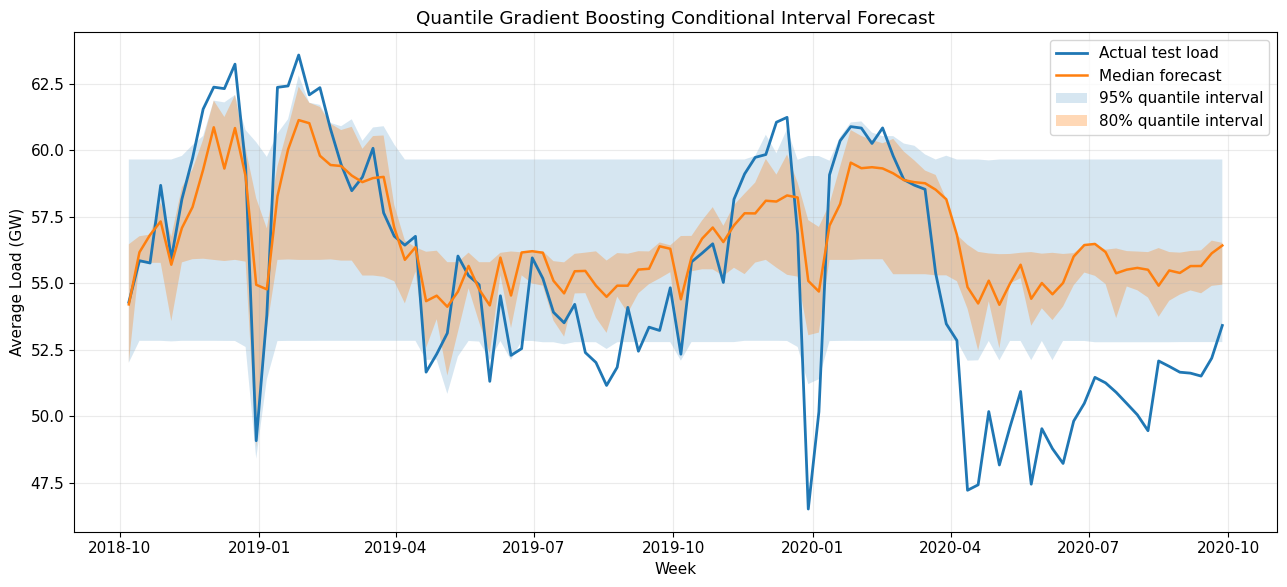

In [ ]:
# ============================================================
# CELL 10: QUANTILE GRADIENT BOOSTING
# ============================================================

# Quantiles used to produce:
# 2.5% and 97.5% = approximate 95% interval
# 10% and 90%    = approximate 80% interval
# 50%            = median point forecast

QUANTILES = [
    0.025,
    0.10,
    0.50,
    0.90,
    0.975
]

LOAD_LAGS = [
    1,
    2,
    4,
    13,
    26,
    52
]

ML_EXOG_COLUMNS = [
    "temperature_mean",
    "heating_degree",
    "cooling_degree",
    "holiday_count",
    "has_holiday",
    "christmas_new_year"
]


def create_training_features(
    load_series,
    external_features
):
    """
    Create leakage-safe supervised training features.

    Rolling calculations are shifted by one week so that
    the current target cannot enter its own predictors.
    """
    feature_frame = pd.DataFrame(
        index=load_series.index
    )

    feature_frame["target"] = load_series

    for lag in LOAD_LAGS:
        feature_frame[
            f"load_lag_{lag}"
        ] = load_series.shift(lag)

    shifted_load = load_series.shift(1)

    for window in [4, 13, 52]:
        feature_frame[
            f"rolling_mean_{window}"
        ] = shifted_load.rolling(
            window
        ).mean()

    for window in [4, 13]:
        feature_frame[
            f"rolling_std_{window}"
        ] = shifted_load.rolling(
            window
        ).std()

    week_number = (
        feature_frame
        .index
        .isocalendar()
        .week
        .astype(int)
    )

    feature_frame["week_sin"] = np.sin(
        2
        * np.pi
        * week_number
        / SEASONAL_PERIOD
    )

    feature_frame["week_cos"] = np.cos(
        2
        * np.pi
        * week_number
        / SEASONAL_PERIOD
    )

    # A deterministic time trend is available at the forecast origin.
    feature_frame["trend"] = np.arange(
        len(feature_frame),
        dtype=float
    )

    feature_frame = feature_frame.join(
        external_features[
            ML_EXOG_COLUMNS
        ]
    )

    return feature_frame.dropna()


def create_recursive_feature_row(
    history,
    forecast_date,
    external_row,
    trend_position,
    required_columns
):
    """
    Construct features for one future week.

    The history contains:
    - actual load up to the training endpoint;
    - predicted median load after the forecast origin.
    """
    feature_values = {}

    for lag in LOAD_LAGS:
        feature_values[
            f"load_lag_{lag}"
        ] = float(
            history.iloc[-lag]
        )

    for window in [4, 13, 52]:
        feature_values[
            f"rolling_mean_{window}"
        ] = float(
            history.iloc[-window:].mean()
        )

    for window in [4, 13]:
        feature_values[
            f"rolling_std_{window}"
        ] = float(
            history.iloc[-window:].std()
        )

    week_number = int(
        forecast_date.isocalendar().week
    )

    feature_values["week_sin"] = np.sin(
        2
        * np.pi
        * week_number
        / SEASONAL_PERIOD
    )

    feature_values["week_cos"] = np.cos(
        2
        * np.pi
        * week_number
        / SEASONAL_PERIOD
    )

    feature_values["trend"] = float(
        trend_position
    )

    for column in ML_EXOG_COLUMNS:
        feature_values[column] = float(
            external_row[column]
        )

    feature_row = pd.DataFrame(
        [feature_values],
        index=[forecast_date]
    )

    return feature_row.reindex(
        columns=required_columns
    )


def recursive_median_forecast(
    fitted_model,
    history,
    forecast_dates,
    external_features,
    feature_columns,
    complete_week_index
):
    """
    Produce recursive validation forecasts using a median model.
    """
    recursive_history = history.copy()

    predictions = []

    trend_lookup = {
        date: position
        for position, date in enumerate(
            complete_week_index
        )
    }

    for forecast_date in forecast_dates:

        feature_row = (
            create_recursive_feature_row(
                history=recursive_history,
                forecast_date=forecast_date,
                external_row=(
                    external_features.loc[
                        forecast_date
                    ]
                ),
                trend_position=(
                    trend_lookup[
                        forecast_date
                    ]
                ),
                required_columns=(
                    feature_columns
                )
            )
        )

        predicted_value = float(
            fitted_model.predict(
                feature_row
            )[0]
        )

        predictions.append(
            predicted_value
        )

        recursive_history = pd.concat(
            [
                recursive_history,
                pd.Series(
                    [predicted_value],
                    index=[forecast_date]
                )
            ]
        )

    return pd.Series(
        predictions,
        index=forecast_dates
    )


# -----------------------------
# Create model training data
# -----------------------------

external_weekly_features = weekly_data[
    ML_EXOG_COLUMNS
]

quantile_training_frame = (
    create_training_features(
        load_series=train,
        external_features=(
            external_weekly_features.loc[
                train.index
            ]
        )
    )
)

X_quantile_train = (
    quantile_training_frame
    .drop(columns="target")
)

y_quantile_train = (
    quantile_training_frame["target"]
)


print(
    "Quantile model training rows:",
    len(quantile_training_frame)
)

print(
    "Number of model features:",
    X_quantile_train.shape[1]
)


# -----------------------------
# Candidate hyperparameters
# -----------------------------

quantile_candidates = [
    {
        "n_estimators": 200,
        "learning_rate": 0.03,
        "max_depth": 2,
        "min_samples_leaf": 5,
        "subsample": 0.8
    },
    {
        "n_estimators": 300,
        "learning_rate": 0.03,
        "max_depth": 2,
        "min_samples_leaf": 10,
        "subsample": 1.0
    },
    {
        "n_estimators": 300,
        "learning_rate": 0.05,
        "max_depth": 2,
        "min_samples_leaf": 5,
        "subsample": 0.8
    },
    {
        "n_estimators": 400,
        "learning_rate": 0.03,
        "max_depth": 3,
        "min_samples_leaf": 5,
        "subsample": 0.8
    },
    {
        "n_estimators": 300,
        "learning_rate": 0.05,
        "max_depth": 3,
        "min_samples_leaf": 10,
        "subsample": 1.0
    },
    {
        "n_estimators": 500,
        "learning_rate": 0.02,
        "max_depth": 3,
        "min_samples_leaf": 5,
        "subsample": 0.8
    }
]


def create_expanding_validation_folds(
    training_index,
    number_of_folds=4,
    validation_horizon=13
):
    """
    Create expanding-window validation folds.

    Every validation period occurs after its corresponding
    training period.
    """
    total_validation_length = (
        number_of_folds
        * validation_horizon
    )

    first_validation_position = (
        len(training_index)
        - total_validation_length
    )

    folds = []

    for fold_number in range(
        number_of_folds
    ):

        validation_start = (
            first_validation_position
            + fold_number
            * validation_horizon
        )

        validation_end = (
            validation_start
            + validation_horizon
        )

        fold_training_dates = (
            training_index[
                :validation_start
            ]
        )

        fold_validation_dates = (
            training_index[
                validation_start:
                validation_end
            ]
        )

        folds.append(
            (
                fold_training_dates,
                fold_validation_dates
            )
        )

    return folds


def tune_quantile_median_model():
    """
    Select hyperparameters using recursive validation MAE.

    Only the 0.50 median model is tuned. The selected
    hyperparameters are then applied consistently to every
    quantile model.
    """
    validation_folds = (
        create_expanding_validation_folds(
            train.index,
            number_of_folds=4,
            validation_horizon=13
        )
    )

    tuning_rows = []

    for candidate_number, parameters in enumerate(
        quantile_candidates,
        start=1
    ):

        fold_mae_values = []

        for (
            fold_training_dates,
            fold_validation_dates
        ) in validation_folds:

            fold_training_load = train.loc[
                fold_training_dates
            ]

            fold_training_external = (
                external_weekly_features.loc[
                    fold_training_dates
                ]
            )

            fold_training_frame = (
                create_training_features(
                    load_series=(
                        fold_training_load
                    ),
                    external_features=(
                        fold_training_external
                    )
                )
            )

            X_fold = fold_training_frame.drop(
                columns="target"
            )

            y_fold = fold_training_frame[
                "target"
            ]

            median_model = (
                GradientBoostingRegressor(
                    loss="quantile",
                    alpha=0.50,
                    random_state=RANDOM_STATE,
                    **parameters
                )
            )

            median_model.fit(
                X_fold,
                y_fold
            )

            validation_forecast = (
                recursive_median_forecast(
                    fitted_model=median_model,
                    history=fold_training_load,
                    forecast_dates=(
                        fold_validation_dates
                    ),
                    external_features=(
                        external_weekly_features
                    ),
                    feature_columns=(
                        X_fold.columns
                    ),
                    complete_week_index=(
                        weekly_data.index
                    )
                )
            )

            validation_actual = train.loc[
                fold_validation_dates
            ]

            fold_mae_values.append(
                mean_absolute_error(
                    validation_actual,
                    validation_forecast
                )
            )

        tuning_result = parameters.copy()

        tuning_result[
            "Mean recursive validation MAE"
        ] = np.mean(
            fold_mae_values
        )

        tuning_result[
            "Validation MAE standard deviation"
        ] = np.std(
            fold_mae_values
        )

        tuning_rows.append(
            tuning_result
        )

        print(
            f"Completed Quantile Gradient Boosting "
            f"candidate {candidate_number}/"
            f"{len(quantile_candidates)}"
        )

    return (
        pd.DataFrame(tuning_rows)
        .sort_values(
            "Mean recursive validation MAE"
        )
        .reset_index(drop=True)
    )


if RUN_QUANTILE_TUNING:

    quantile_tuning_results = (
        tune_quantile_median_model()
    )

    quantile_tuning_results.to_csv(
        RESULTS_DIR
        / "quantile_gradient_boosting_tuning.csv",
        index=False
    )

else:

    quantile_tuning_results = pd.read_csv(
        RESULTS_DIR
        / "quantile_gradient_boosting_tuning.csv"
    ).sort_values(
        "Mean recursive validation MAE"
    )


display(
    quantile_tuning_results.round(4)
)


# Extract the selected parameter values.
best_quantile_parameters = {
    parameter: (
        quantile_tuning_results.iloc[0][
            parameter
        ]
    )
    for parameter in [
        "n_estimators",
        "learning_rate",
        "max_depth",
        "min_samples_leaf",
        "subsample"
    ]
}


# Convert integer parameters read from a CSV back to integers.
best_quantile_parameters[
    "n_estimators"
] = int(
    best_quantile_parameters[
        "n_estimators"
    ]
)

best_quantile_parameters[
    "max_depth"
] = int(
    best_quantile_parameters[
        "max_depth"
    ]
)

best_quantile_parameters[
    "min_samples_leaf"
] = int(
    best_quantile_parameters[
        "min_samples_leaf"
    ]
)


print(
    "Selected Quantile Gradient Boosting parameters:"
)

print(
    best_quantile_parameters
)


# -----------------------------
# Fit five quantile models
# -----------------------------

quantile_models = {}

for quantile in QUANTILES:

    model = GradientBoostingRegressor(
        loss="quantile",
        alpha=quantile,
        random_state=RANDOM_STATE,
        **best_quantile_parameters
    )

    model.fit(
        X_quantile_train,
        y_quantile_train
    )

    quantile_models[quantile] = model


def create_recursive_quantile_forecast():
    """
    Recursively forecast every test week.

    The median prediction is added to history after each step.
    This prevents actual test-period demand from leaking into
    later lagged and rolling features.
    """
    ordered_quantiles = sorted(
        quantile_models.keys()
    )

    recursive_history = train.copy()

    forecast_rows = []

    quantile_crossing_count = 0

    trend_lookup = {
        date: position
        for position, date in enumerate(
            weekly_data.index
        )
    }

    for forecast_date in test.index:

        feature_row = (
            create_recursive_feature_row(
                history=recursive_history,
                forecast_date=forecast_date,
                external_row=(
                    external_weekly_features.loc[
                        forecast_date
                    ]
                ),
                trend_position=(
                    trend_lookup[
                        forecast_date
                    ]
                ),
                required_columns=(
                    X_quantile_train.columns
                )
            )
        )

        raw_predictions = np.array(
            [
                float(
                    quantile_models[
                        quantile
                    ].predict(
                        feature_row
                    )[0]
                )
                for quantile in ordered_quantiles
            ]
        )

        if np.any(
            np.diff(raw_predictions) < 0
        ):
            quantile_crossing_count += 1

        # Ensure interval boundaries remain ordered.
        corrected_predictions = (
            np.maximum.accumulate(
                raw_predictions
            )
        )

        forecast_row = {
            quantile: prediction
            for quantile, prediction
            in zip(
                ordered_quantiles,
                corrected_predictions
            )
        }

        forecast_rows.append(
            forecast_row
        )

        median_prediction = (
            forecast_row[0.50]
        )

        recursive_history = pd.concat(
            [
                recursive_history,
                pd.Series(
                    [median_prediction],
                    index=[forecast_date]
                )
            ]
        )

    quantile_forecasts = pd.DataFrame(
        forecast_rows,
        index=test.index
    )

    return (
        quantile_forecasts,
        quantile_crossing_count
    )


quantile_forecasts, quantile_crossing_count = (
    create_recursive_quantile_forecast()
)


print(
    "Weeks with raw quantile crossing:",
    quantile_crossing_count
)


quantile_median_forecast = (
    quantile_forecasts[0.50]
    .rename(
        "Quantile Gradient Boosting"
    )
)


quantile_interval_80 = pd.DataFrame(
    {
        "lower": quantile_forecasts[0.10],
        "upper": quantile_forecasts[0.90]
    },
    index=test.index
)


quantile_interval_95 = pd.DataFrame(
    {
        "lower": quantile_forecasts[0.025],
        "upper": quantile_forecasts[0.975]
    },
    index=test.index
)


point_forecasts[
    "Quantile Gradient Boosting"
] = quantile_median_forecast

point_metric_rows.append(
    evaluate_point_forecast(
        model_name=(
            "Quantile Gradient Boosting"
        ),
        actual=test,
        forecast=quantile_median_forecast,
        training_series=train
    )
)


# -----------------------------
# Quantile forecast plot
# -----------------------------

plt.figure(figsize=(13, 6))

plt.plot(
    test.index,
    test,
    label="Actual test load",
    linewidth=2
)

plt.plot(
    quantile_median_forecast.index,
    quantile_median_forecast,
    label="Median forecast",
    linewidth=1.8
)

plt.fill_between(
    quantile_interval_95.index,
    quantile_interval_95["lower"],
    quantile_interval_95["upper"],
    alpha=0.18,
    label="95% quantile interval"
)

plt.fill_between(
    quantile_interval_80.index,
    quantile_interval_80["lower"],
    quantile_interval_80["upper"],
    alpha=0.30,
    label="80% quantile interval"
)

plt.title(
    "Quantile Gradient Boosting Conditional Interval Forecast"
)

plt.xlabel("Week")
plt.ylabel("Average Load (GW)")
plt.legend()
plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "quantile_gradient_boosting_intervals.png",
    dpi=300
)

plt.show()

Hourly training period: 2015-01-01 00:00:00 to 2018-09-30 23:00:00
Hourly testing period: 2018-10-01 00:00:00 to 2020-09-27 23:00:00
LSTM training sequences: (1090, 168, 1)
LSTM validation sequences: (272, 168, 1)
Epoch 1/35
18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 50ms/step - loss: 0.2725 - mae: 0.4756 - val_loss: 0.2208 - val_mae: 0.4214
Epoch 2/35
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - loss: 0.1330 - mae: 0.2957 - val_loss: 0.0581 - val_mae: 0.1879
Epoch 3/35
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - loss: 0.0472 - mae: 0.1715 - val_loss: 0.0218 - val_mae: 0.1230
Epoch 4/35
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - loss: 0.0317 - mae: 0.1421 - val_loss: 0.0197 - val_mae: 0.1205
Epoch 5/35
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 51ms/step - loss: 0.0280 - mae: 0.1346 - val_loss: 0.0187 - val_mae: 0.1160
Epoch 6/35
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 61ms/step - loss: 0.0271 - mae: 0.1318 - val_loss: 0.0186 - val_mae: 0.1158
Epoch 7/35
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - loss: 0.0259 - mae: 0.1288 - va

,units,number_of_layers,dropout_rate,learning_rate,Minimum validation loss,Epochs trained
0,64,2,0.2,0.001,0.008212,26
1,32,1,0.1,0.001,0.012093,35
2,64,1,0.2,0.001,0.017288,16


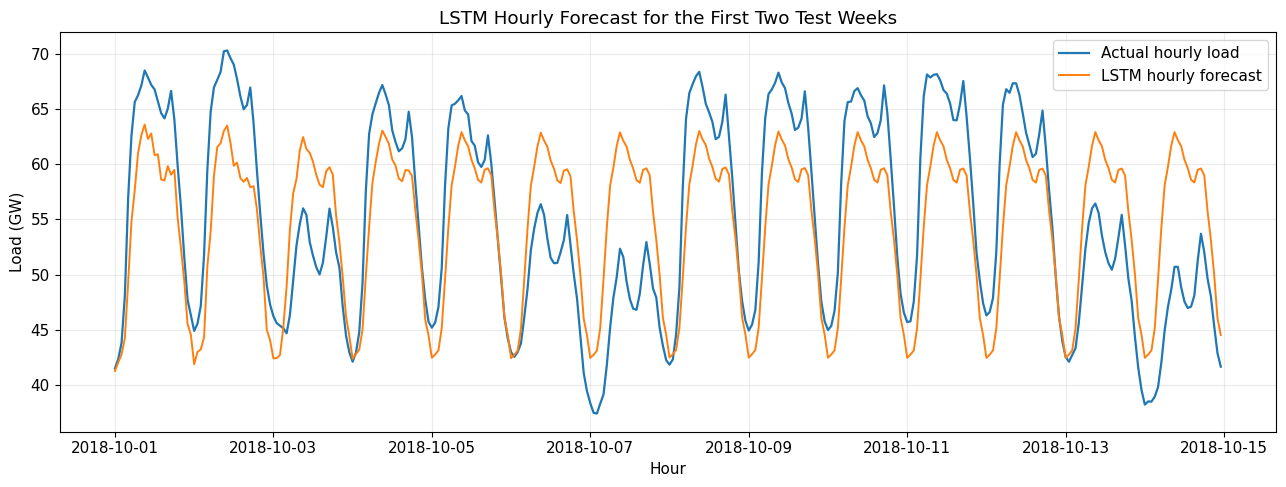

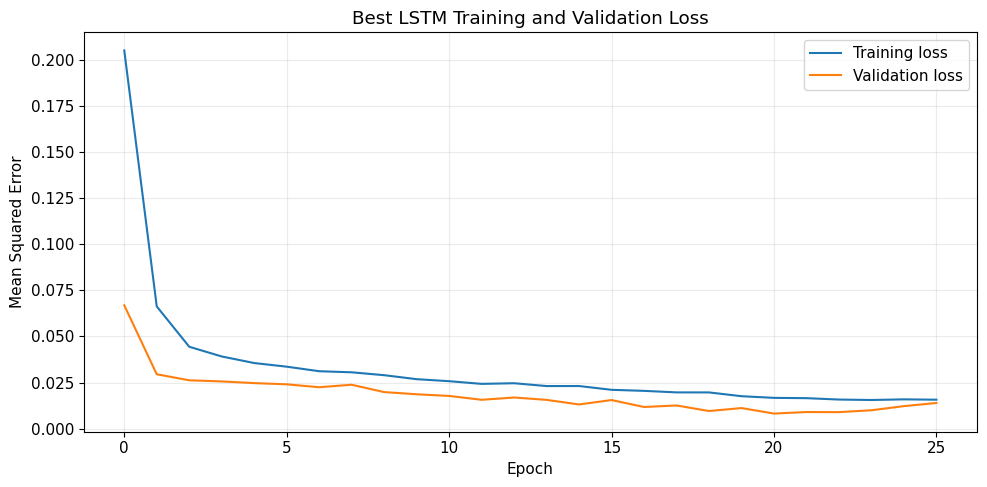

In [ ]:
# ============================================================
# CELL 11: HOURLY LSTM MODEL
# ============================================================

# TensorFlow is normally pre-installed in Google Colab.
# Run the following once if required:
# %pip install -q tensorflow

if RUN_LSTM:

    import tensorflow as tf

    from tensorflow.keras import Sequential

    from tensorflow.keras.callbacks import (
        EarlyStopping
    )

    from tensorflow.keras.layers import (
        Dense,
        Dropout,
        Input,
        LSTM
    )

    from tensorflow.keras.optimizers import Adam


    tf.random.set_seed(
        RANDOM_STATE
    )


    # A 168-hour window contains one complete weekly cycle.
    LOOKBACK_HOURS = 168

    # The model predicts the next 24 hours in one block.
    OUTPUT_HOURS = 24


    # --------------------------------------------------------
    # Define hourly training and testing periods
    # --------------------------------------------------------

    # Each weekly test observation is labelled on Sunday.
    # Therefore, the first hourly test value begins on the
    # Monday six days before the first weekly test label.
    hourly_test_start = (
        test.index[0]
        - pd.Timedelta(days=6)
    )

    hourly_test_end = (
        test.index[-1]
        + pd.Timedelta(hours=23)
    )

    hourly_train = hourly_load.loc[
        :hourly_test_start
        - pd.Timedelta(hours=1)
    ].copy()

    hourly_test = hourly_load.loc[
        hourly_test_start:
        hourly_test_end
    ].copy()


    print(
        "Hourly training period:",
        hourly_train.index.min(),
        "to",
        hourly_train.index.max()
    )

    print(
        "Hourly testing period:",
        hourly_test.index.min(),
        "to",
        hourly_test.index.max()
    )


    # --------------------------------------------------------
    # Scale using training data only
    # --------------------------------------------------------

    hourly_scaler = MinMaxScaler()

    hourly_train_scaled = (
        hourly_scaler.fit_transform(
            hourly_train
            .to_numpy()
            .reshape(-1, 1)
        )
    )


    def create_lstm_sequences(
        scaled_values,
        lookback,
        output_horizon,
        stride=24
    ):
        """
        Create chronological LSTM sequences.

        A stride of 24 reduces duplicated overlapping samples
        and makes training more manageable.
        """
        X_sequences = []
        y_sequences = []

        maximum_start = (
            len(scaled_values)
            - lookback
            - output_horizon
            + 1
        )

        for start_position in range(
            0,
            maximum_start,
            stride
        ):

            input_end = (
                start_position
                + lookback
            )

            output_end = (
                input_end
                + output_horizon
            )

            X_sequences.append(
                scaled_values[
                    start_position:
                    input_end
                ]
            )

            y_sequences.append(
                scaled_values[
                    input_end:
                    output_end,
                    0
                ]
            )

        return (
            np.asarray(
                X_sequences,
                dtype=np.float32
            ),
            np.asarray(
                y_sequences,
                dtype=np.float32
            )
        )


    X_lstm, y_lstm = (
        create_lstm_sequences(
            scaled_values=hourly_train_scaled,
            lookback=LOOKBACK_HOURS,
            output_horizon=OUTPUT_HOURS,
            stride=24
        )
    )


    # Use the final 20% of training sequences as validation.
    validation_size = int(
        len(X_lstm) * 0.20
    )

    X_lstm_train = X_lstm[
        :-validation_size
    ]

    y_lstm_train = y_lstm[
        :-validation_size
    ]

    X_lstm_validation = X_lstm[
        -validation_size:
    ]

    y_lstm_validation = y_lstm[
        -validation_size:
    ]


    print(
        "LSTM training sequences:",
        X_lstm_train.shape
    )

    print(
        "LSTM validation sequences:",
        X_lstm_validation.shape
    )


    def build_lstm_model(
        units,
        number_of_layers,
        dropout_rate,
        learning_rate
    ):
        """
        Build one candidate LSTM architecture.
        """
        model = Sequential()

        model.add(
            Input(
                shape=(
                    LOOKBACK_HOURS,
                    1
                )
            )
        )

        if number_of_layers == 1:

            model.add(
                LSTM(units)
            )

        else:

            model.add(
                LSTM(
                    units,
                    return_sequences=True
                )
            )

            model.add(
                Dropout(
                    dropout_rate
                )
            )

            model.add(
                LSTM(
                    max(
                        units // 2,
                        16
                    )
                )
            )

        model.add(
            Dropout(
                dropout_rate
            )
        )

        model.add(
            Dense(
                OUTPUT_HOURS
            )
        )

        model.compile(
            optimizer=Adam(
                learning_rate=(
                    learning_rate
                )
            ),
            loss="mse",
            metrics=["mae"]
        )

        return model


    # Small architecture search to demonstrate hyperparameter tuning.
    lstm_candidates = [
        {
            "units": 32,
            "number_of_layers": 1,
            "dropout_rate": 0.10,
            "learning_rate": 0.001
        },
        {
            "units": 64,
            "number_of_layers": 1,
            "dropout_rate": 0.20,
            "learning_rate": 0.001
        },
        {
            "units": 64,
            "number_of_layers": 2,
            "dropout_rate": 0.20,
            "learning_rate": 0.001
        }
    ]


    lstm_tuning_rows = []

    best_validation_loss = np.inf

    best_lstm_model = None

    best_lstm_history = None


    for candidate_number, parameters in enumerate(
        lstm_candidates,
        start=1
    ):

        tf.keras.backend.clear_session()

        candidate_model = build_lstm_model(
            **parameters
        )

        early_stopping = EarlyStopping(
            monitor="val_loss",
            patience=5,
            restore_best_weights=True
        )

        model_history = candidate_model.fit(
            X_lstm_train,
            y_lstm_train,
            validation_data=(
                X_lstm_validation,
                y_lstm_validation
            ),
            epochs=35,
            batch_size=64,
            callbacks=[
                early_stopping
            ],
            verbose=1
        )

        minimum_validation_loss = min(
            model_history.history[
                "val_loss"
            ]
        )

        tuning_row = parameters.copy()

        tuning_row[
            "Minimum validation loss"
        ] = minimum_validation_loss

        tuning_row[
            "Epochs trained"
        ] = len(
            model_history.history[
                "loss"
            ]
        )

        lstm_tuning_rows.append(
            tuning_row
        )

        if (
            minimum_validation_loss
            < best_validation_loss
        ):

            best_validation_loss = (
                minimum_validation_loss
            )

            best_lstm_model = (
                candidate_model
            )

            best_lstm_history = (
                model_history.history
            )

        print(
            f"Completed LSTM candidate "
            f"{candidate_number}/"
            f"{len(lstm_candidates)}"
        )


    lstm_tuning_table = (
        pd.DataFrame(
            lstm_tuning_rows
        )
        .sort_values(
            "Minimum validation loss"
        )
        .reset_index(drop=True)
    )

    display(
        lstm_tuning_table.round(6)
    )

    lstm_tuning_table.to_csv(
        RESULTS_DIR / "lstm_tuning.csv",
        index=False
    )


    def recursive_lstm_forecast(
        fitted_model,
        scaled_training_values,
        forecast_length
    ):
        """
        Produce a fixed-origin recursive forecast in 24-hour blocks.

        Predicted hourly values are fed back into the next input
        window. Actual test values are not used.
        """
        recursive_history = (
            scaled_training_values[
                :, 0
            ]
            .astype(float)
            .tolist()
        )

        predictions = []

        while len(predictions) < forecast_length:

            input_window = np.asarray(
                recursive_history[
                    -LOOKBACK_HOURS:
                ],
                dtype=np.float32
            ).reshape(
                1,
                LOOKBACK_HOURS,
                1
            )

            predicted_block = (
                fitted_model.predict(
                    input_window,
                    verbose=0
                )
                .reshape(-1)
            )

            remaining_length = (
                forecast_length
                - len(predictions)
            )

            predicted_block = (
                predicted_block[
                    :remaining_length
                ]
            )

            predictions.extend(
                predicted_block.tolist()
            )

            recursive_history.extend(
                predicted_block.tolist()
            )

        return np.asarray(
            predictions
        )


    scaled_lstm_forecast = (
        recursive_lstm_forecast(
            fitted_model=best_lstm_model,
            scaled_training_values=(
                hourly_train_scaled
            ),
            forecast_length=len(
                hourly_test
            )
        )
    )


    # Return predictions to the original GW scale.
    hourly_lstm_values = (
        hourly_scaler.inverse_transform(
            scaled_lstm_forecast.reshape(
                -1,
                1
            )
        )
        .reshape(-1)
    )


    hourly_lstm_forecast = pd.Series(
        hourly_lstm_values,
        index=hourly_test.index,
        name="LSTM hourly forecast"
    )


    # Aggregate the hourly forecast to weekly means so it can
    # be compared with weekly models.
    lstm_week_period = (
        hourly_lstm_forecast
        .index
        .to_period("W-SUN")
    )

    weekly_lstm_forecast = (
        hourly_lstm_forecast
        .groupby(lstm_week_period)
        .mean()
    )

    weekly_lstm_forecast.index = (
        weekly_lstm_forecast
        .index
        .end_time
        .normalize()
    )

    weekly_lstm_forecast = (
        weekly_lstm_forecast
        .reindex(test.index)
    )


    if weekly_lstm_forecast.isna().any():
        raise ValueError(
            "The LSTM weekly forecast did not align "
            "with every weekly test observation."
        )


    weekly_lstm_forecast.name = "LSTM"


    point_forecasts[
        "LSTM"
    ] = weekly_lstm_forecast


    point_metric_rows.append(
        evaluate_point_forecast(
            model_name="LSTM",
            actual=test,
            forecast=weekly_lstm_forecast,
            training_series=train
        )
    )


    # --------------------------------------------------------
    # Plot: first two weeks of hourly LSTM predictions
    # --------------------------------------------------------

    sample_length = min(
        24 * 14,
        len(hourly_test)
    )

    plt.figure(figsize=(13, 5))

    plt.plot(
        hourly_test.index[:sample_length],
        hourly_test.iloc[:sample_length],
        label="Actual hourly load",
        linewidth=1.6
    )

    plt.plot(
        hourly_lstm_forecast.index[
            :sample_length
        ],
        hourly_lstm_forecast.iloc[
            :sample_length
        ],
        label="LSTM hourly forecast",
        linewidth=1.4
    )

    plt.title(
        "LSTM Hourly Forecast for the First Two Test Weeks"
    )

    plt.xlabel("Hour")
    plt.ylabel("Load (GW)")
    plt.legend()
    plt.tight_layout()

    plt.savefig(
        FIGURES_DIR / "lstm_hourly_forecast_sample.png",
        dpi=300
    )

    plt.show()


    # --------------------------------------------------------
    # Plot: training and validation loss
    # --------------------------------------------------------

    plt.figure(figsize=(10, 5))

    plt.plot(
        best_lstm_history["loss"],
        label="Training loss"
    )

    plt.plot(
        best_lstm_history["val_loss"],
        label="Validation loss"
    )

    plt.title(
        "Best LSTM Training and Validation Loss"
    )

    plt.xlabel("Epoch")
    plt.ylabel("Mean Squared Error")
    plt.legend()
    plt.tight_layout()

    plt.savefig(
        FIGURES_DIR / "lstm_learning_curve.png",
        dpi=300
    )

    plt.show()

else:

    print(
        "LSTM section skipped because RUN_LSTM is False."
    )

FINAL POINT-FORECAST METRICS


,Model,MAE,RMSE,sMAPE (%),MASE,Bias (forecast - actual),RMSE improvement over seasonal naive (%)
0,Seasonal naive,2.288,2.988,4.207,1.694,1.748,0.000
1,Quantile Gradient Boosting,2.594,3.286,4.777,1.920,1.548,-9.953
2,SARIMAX full,2.812,3.570,5.138,2.081,2.720,-19.483
3,SARIMAX temperature,3.070,3.854,5.595,2.272,2.936,-28.968
4,SARIMA,3.308,4.038,5.987,2.448,3.143,-35.137
5,SARIMAX calendar,3.383,4.073,6.102,2.504,3.331,-36.311
6,Mean,3.790,4.402,6.874,2.805,0.561,-47.312
7,LSTM,3.744,4.412,6.792,2.771,-0.637,-47.652
8,Drift,3.851,4.466,6.982,2.850,0.966,-49.469
9,Naive,3.858,4.476,6.995,2.856,0.985,-49.779


PREDICTION-INTERVAL METRICS


,Model,Nominal coverage,Actual coverage (PICP),Coverage difference,Mean interval width (MPIW),Mean interval score,Below lower boundary,Above upper boundary
0,SARIMA,0.80,0.3846,-0.4154,4.8872,17.0522,63,1
1,Quantile Gradient Boosting,0.80,0.3173,-0.4827,2.9957,18.5029,47,24
2,SARIMAX calendar,0.80,0.2404,-0.5596,4.1238,19.4166,79,0
3,SARIMAX temperature,0.80,0.3365,-0.4635,3.3037,20.0571,68,1
4,SARIMAX full,0.80,0.2788,-0.5212,2.2932,20.4218,75,0
5,SARIMA,0.95,0.7019,-0.2481,7.4743,29.7431,31,0
6,SARIMAX calendar,0.95,0.5288,-0.4212,6.3069,38.3474,49,0
7,Quantile Gradient Boosting,0.95,0.5577,-0.3923,7.4054,39.1589,34,12
8,SARIMAX temperature,0.95,0.5096,-0.4404,5.0526,50.6521,51,0
9,SARIMAX full,0.95,0.3558,-0.5942,3.5071,59.3393,67,0


SEASONAL AND HIGH-DEMAND COVERAGE


,Model,Nominal coverage,Subgroup type,Subgroup,Observations,Actual coverage,Mean width
0,SARIMA,0.80,Season,Autumn,25,0.2800,4.6701
1,SARIMA,0.80,Season,Spring,27,0.4074,4.9870
2,SARIMA,0.80,Season,Summer,26,0.2692,5.3734
3,SARIMA,0.80,Season,Winter,26,0.5769,4.5060
4,SARIMA,0.80,Demand level,Other weeks,89,0.2921,5.0028
5,SARIMA,0.80,Demand level,High demand,15,0.9333,4.2008
6,SARIMA,0.95,Season,Autumn,25,0.8400,7.1422
7,SARIMA,0.95,Season,Spring,27,0.5556,7.6270
8,SARIMA,0.95,Season,Summer,26,0.5385,8.2179
9,SARIMA,0.95,Season,Winter,26,0.8846,6.8913


STATISTICAL MODEL RESIDUAL DIAGNOSTICS


,Model,Residual mean,Residual standard deviation,Residual skewness,Residual kurtosis,Ljung-Box p-value lag 10,Ljung-Box p-value lag 20,Ljung-Box p-value lag 52
0,SARIMA,-0.1331,1.2816,0.0021,0.1533,0.9879,0.5565,0.7471
1,SARIMAX full,-0.1374,0.8995,0.1751,-0.1995,0.9946,0.7741,0.4663


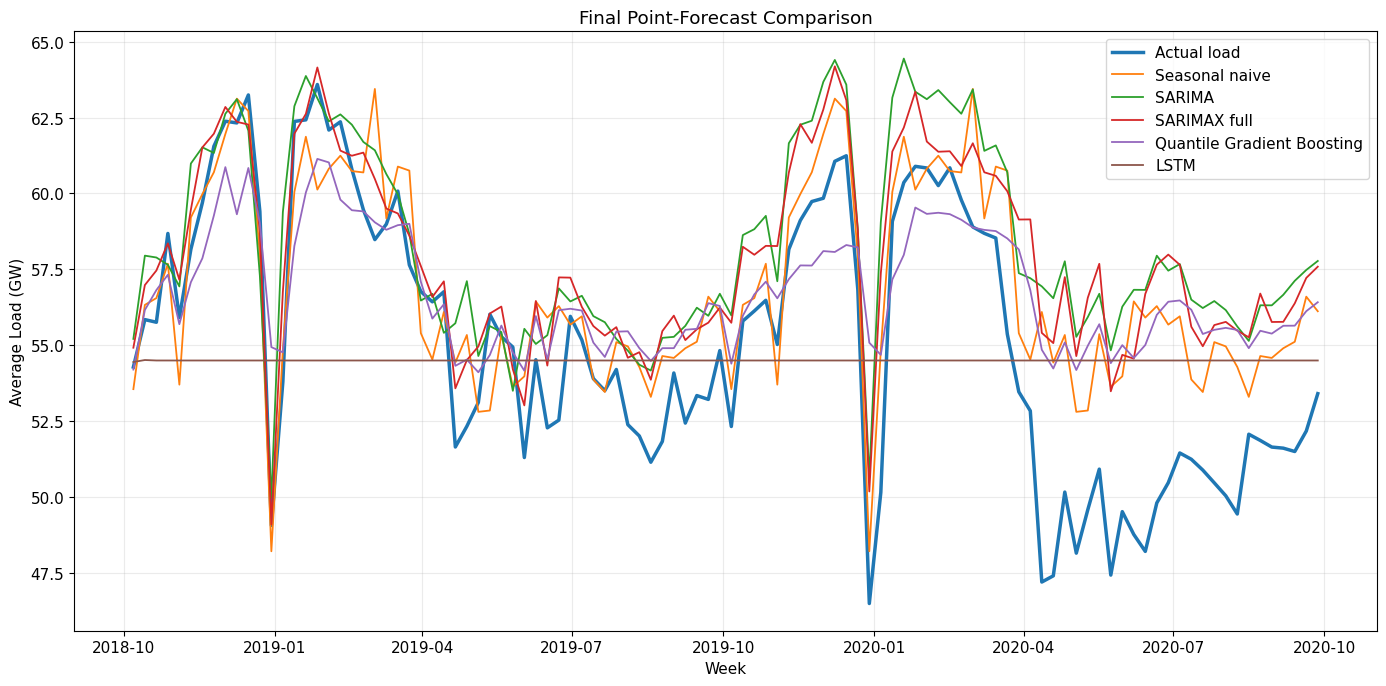

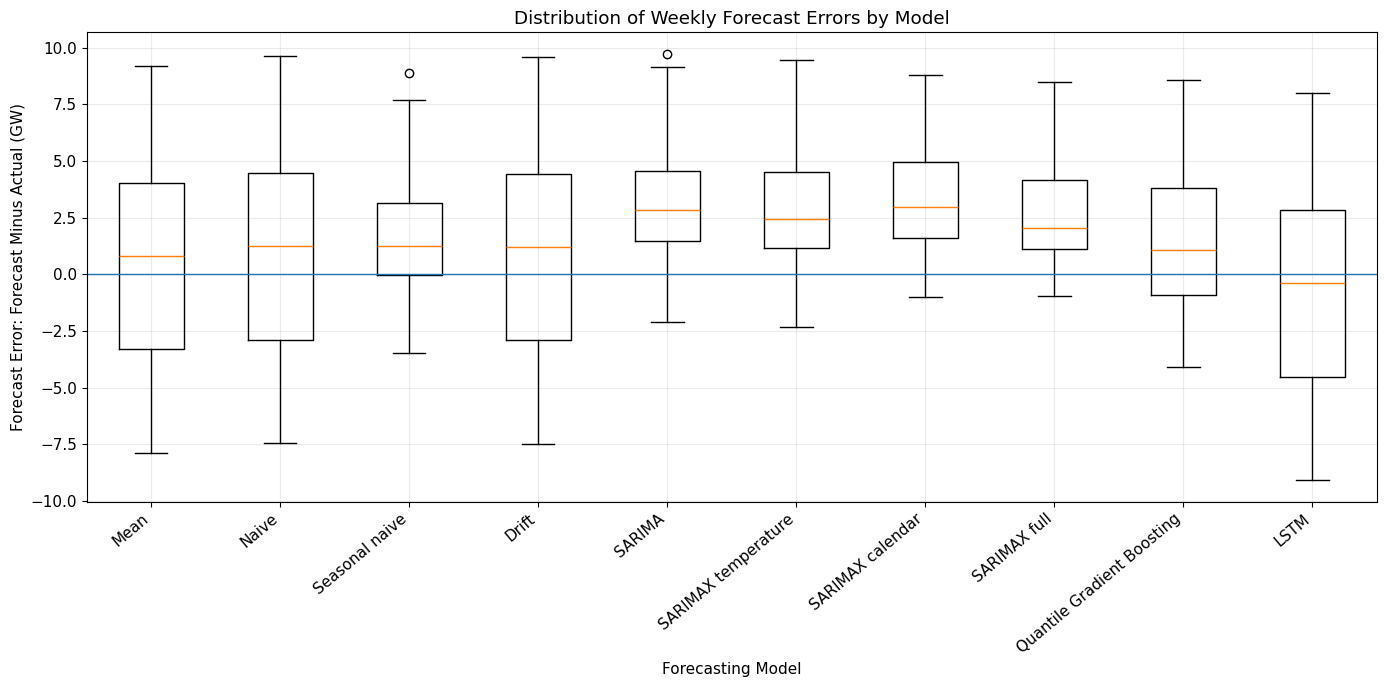

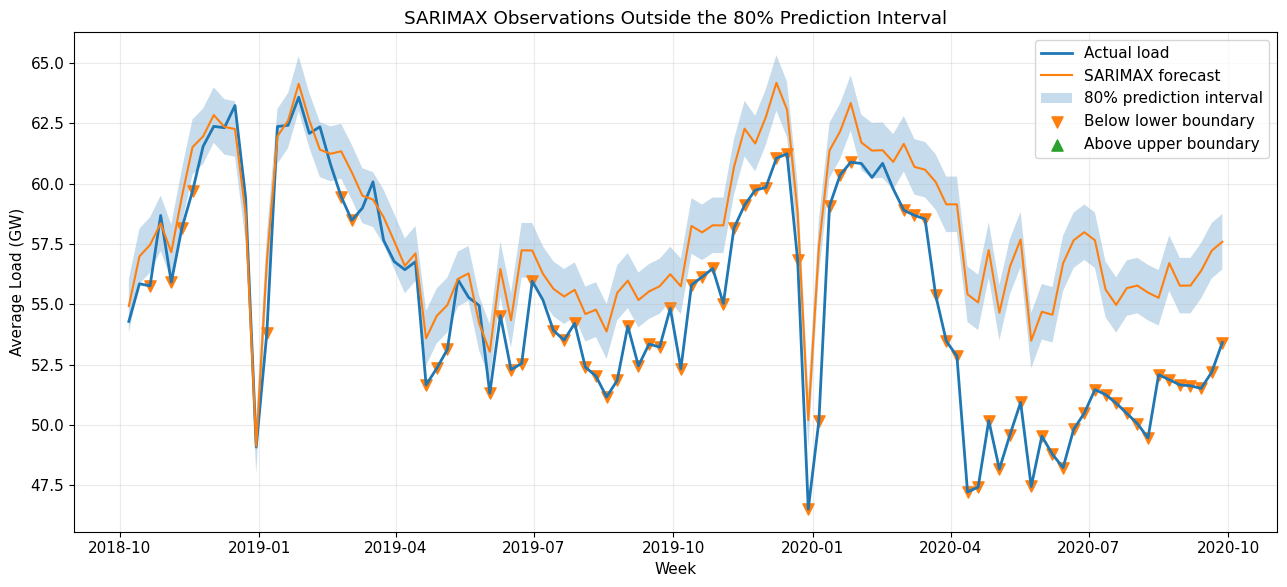

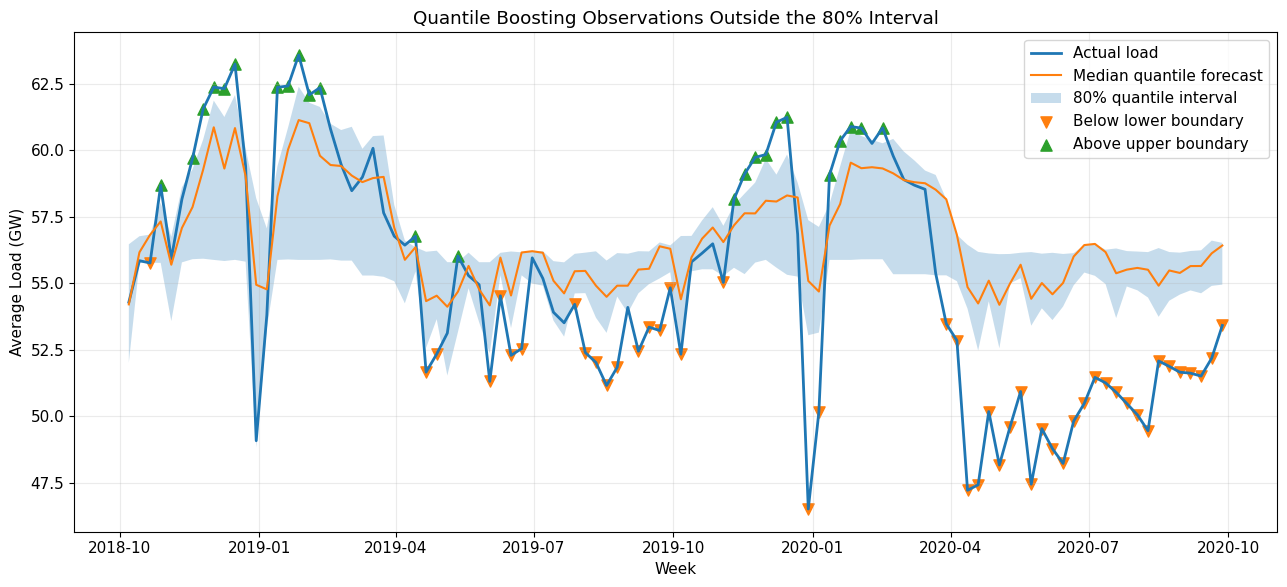

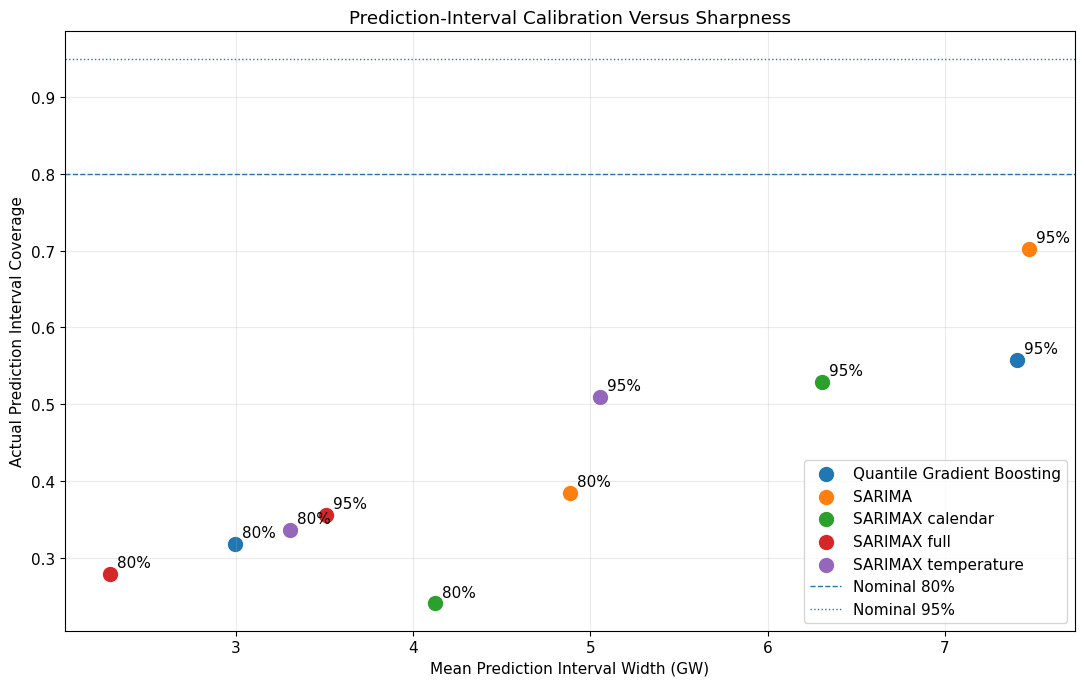

OPERATIONAL USEFULNESS TABLE


,Model,Uncertainty output,Interpretability score (1-5),Maintenance ease score (1-5),Future input requirement,RMSE,MAE,Bias (forecast - actual)
0,Seasonal naive,Point baseline in this study,5,5,Past annual load cycle,2.988,2.288,1.748
1,SARIMA,Model-based intervals,4,4,Past load only,4.038,3.308,3.143
2,SARIMAX full,Conditional model-based intervals,4,3,Observed or forecast temperature and holidays,3.570,2.812,2.720
3,Quantile Gradient Boosting,Constructed quantile intervals,3,3,Observed or forecast temperature and holidays,3.286,2.594,1.548
4,LSTM,Point forecast only,1,1,Past hourly load,4.412,3.744,-0.637


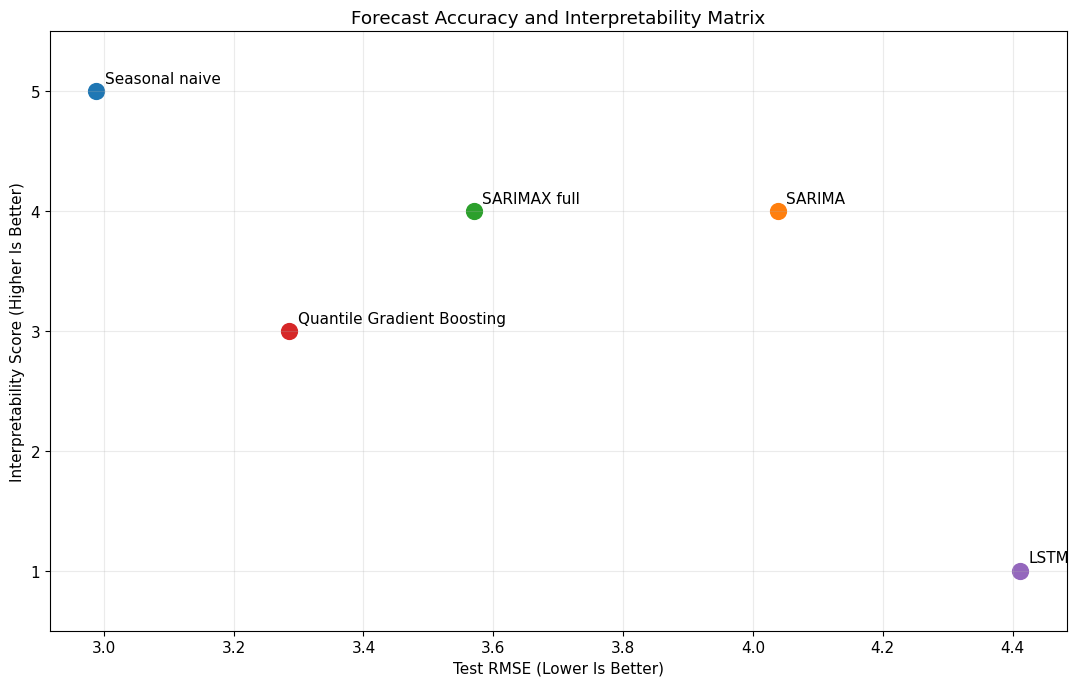

All tables were saved in: /content/results
All figures were saved in: /content/figures


In [16]:
# ============================================================
# CELL 12: FINAL COMPARISON, INTERVAL CALIBRATION AND OUTPUTS
# ============================================================

# ------------------------------------------------------------
# Point-forecast metrics
# ------------------------------------------------------------

point_metrics_table = (
    pd.DataFrame(
        point_metric_rows
    )
    .drop_duplicates(
        subset="Model",
        keep="last"
    )
    .sort_values("RMSE")
    .reset_index(drop=True)
)


seasonal_naive_rmse = (
    point_metrics_table.loc[
        point_metrics_table[
            "Model"
        ] == "Seasonal naive",
        "RMSE"
    ]
    .iloc[0]
)


point_metrics_table[
    "RMSE improvement over seasonal naive (%)"
] = (
    100
    * (
        1
        - point_metrics_table["RMSE"]
        / seasonal_naive_rmse
    )
)


print(
    "FINAL POINT-FORECAST METRICS"
)

display(
    point_metrics_table.round(3)
)


point_metrics_table.to_csv(
    RESULTS_DIR / "final_point_metrics.csv",
    index=False
)


# ------------------------------------------------------------
# Prediction-interval metrics
# ------------------------------------------------------------

interval_models = {
    ("SARIMA", 0.80): (
        sarima_interval_80
    ),
    ("SARIMA", 0.95): (
        sarima_interval_95
    ),
    ("SARIMAX temperature", 0.80): (
        sarimax_temperature[
            "interval_80"
        ]
    ),
    ("SARIMAX temperature", 0.95): (
        sarimax_temperature[
            "interval_95"
        ]
    ),
    ("SARIMAX calendar", 0.80): (
        sarimax_calendar[
            "interval_80"
        ]
    ),
    ("SARIMAX calendar", 0.95): (
        sarimax_calendar[
            "interval_95"
        ]
    ),
    ("SARIMAX full", 0.80): (
        sarimax_full[
            "interval_80"
        ]
    ),
    ("SARIMAX full", 0.95): (
        sarimax_full[
            "interval_95"
        ]
    ),
    (
        "Quantile Gradient Boosting",
        0.80
    ): quantile_interval_80,
    (
        "Quantile Gradient Boosting",
        0.95
    ): quantile_interval_95
}


interval_metric_rows = []

for (
    model_name,
    nominal_coverage
), interval_values in interval_models.items():

    interval_metric_rows.append(
        evaluate_prediction_interval(
            model_name=model_name,
            nominal_coverage=(
                nominal_coverage
            ),
            actual=test,
            lower=interval_values[
                "lower"
            ],
            upper=interval_values[
                "upper"
            ]
        )
    )


interval_metrics_table = (
    pd.DataFrame(
        interval_metric_rows
    )
    .sort_values(
        [
            "Nominal coverage",
            "Mean interval score"
        ]
    )
    .reset_index(drop=True)
)


print(
    "PREDICTION-INTERVAL METRICS"
)

display(
    interval_metrics_table.round(4)
)


interval_metrics_table.to_csv(
    RESULTS_DIR
    / "prediction_interval_metrics.csv",
    index=False
)


# ------------------------------------------------------------
# Coverage by season and high-demand status
# ------------------------------------------------------------

def assign_season(month):
    """
    Convert each calendar month into a meteorological season.
    """
    if month in [12, 1, 2]:
        return "Winter"

    if month in [3, 4, 5]:
        return "Spring"

    if month in [6, 7, 8]:
        return "Summer"

    return "Autumn"


def evaluate_interval_subgroups(
    model_name,
    nominal_coverage,
    actual,
    interval_values
):
    """
    Calculate interval coverage separately by season and
    high-demand status.
    """
    subgroup_data = pd.DataFrame(
        {
            "actual": actual,
            "lower": interval_values[
                "lower"
            ],
            "upper": interval_values[
                "upper"
            ]
        }
    )

    subgroup_data["season"] = [
        assign_season(month)
        for month in subgroup_data.index.month
    ]

    subgroup_data["high_demand"] = (
        subgroup_data["actual"]
        >= high_demand_threshold
    )

    subgroup_data["inside"] = (
        (
            subgroup_data["actual"]
            >= subgroup_data["lower"]
        )
        &
        (
            subgroup_data["actual"]
            <= subgroup_data["upper"]
        )
    )

    subgroup_data["width"] = (
        subgroup_data["upper"]
        - subgroup_data["lower"]
    )

    subgroup_rows = []

    for season_name, season_data in (
        subgroup_data.groupby("season")
    ):

        subgroup_rows.append(
            {
                "Model": model_name,
                "Nominal coverage": (
                    nominal_coverage
                ),
                "Subgroup type": "Season",
                "Subgroup": season_name,
                "Observations": len(
                    season_data
                ),
                "Actual coverage": (
                    season_data[
                        "inside"
                    ].mean()
                ),
                "Mean width": (
                    season_data[
                        "width"
                    ].mean()
                )
            }
        )

    for demand_flag, demand_data in (
        subgroup_data.groupby(
            "high_demand"
        )
    ):

        subgroup_rows.append(
            {
                "Model": model_name,
                "Nominal coverage": (
                    nominal_coverage
                ),
                "Subgroup type": (
                    "Demand level"
                ),
                "Subgroup": (
                    "High demand"
                    if demand_flag
                    else "Other weeks"
                ),
                "Observations": len(
                    demand_data
                ),
                "Actual coverage": (
                    demand_data[
                        "inside"
                    ].mean()
                ),
                "Mean width": (
                    demand_data[
                        "width"
                    ].mean()
                )
            }
        )

    return pd.DataFrame(
        subgroup_rows
    )


subgroup_tables = []

for (
    model_name,
    nominal_coverage
), interval_values in interval_models.items():

    subgroup_tables.append(
        evaluate_interval_subgroups(
            model_name=model_name,
            nominal_coverage=(
                nominal_coverage
            ),
            actual=test,
            interval_values=(
                interval_values
            )
        )
    )


subgroup_coverage_table = pd.concat(
    subgroup_tables,
    ignore_index=True
)


print(
    "SEASONAL AND HIGH-DEMAND COVERAGE"
)

display(
    subgroup_coverage_table.round(4)
)


subgroup_coverage_table.to_csv(
    RESULTS_DIR
    / "interval_coverage_by_subgroup.csv",
    index=False
)


# ------------------------------------------------------------
# Residual diagnostics table
# ------------------------------------------------------------

residual_diagnostics_table = pd.DataFrame(
    [
        sarima_diagnostic_row,
        sarimax_diagnostic_row
    ]
)


print(
    "STATISTICAL MODEL RESIDUAL DIAGNOSTICS"
)

display(
    residual_diagnostics_table.round(4)
)


residual_diagnostics_table.to_csv(
    RESULTS_DIR
    / "residual_diagnostics.csv",
    index=False
)


# ============================================================
# FINAL REPORT FIGURES
# ============================================================

# ------------------------------------------------------------
# Plot 1: Main point-forecast comparison
# ------------------------------------------------------------

plt.figure(figsize=(14, 7))

plt.plot(
    test.index,
    test,
    label="Actual load",
    linewidth=2.5
)

models_to_plot = [
    "Seasonal naive",
    "SARIMA",
    "SARIMAX full",
    "Quantile Gradient Boosting",
    "LSTM"
]

for model_name in models_to_plot:

    if model_name in point_forecasts:

        plt.plot(
            point_forecasts[
                model_name
            ].index,
            point_forecasts[
                model_name
            ],
            label=model_name,
            linewidth=1.3
        )

plt.title(
    "Final Point-Forecast Comparison"
)

plt.xlabel("Week")
plt.ylabel("Average Load (GW)")
plt.legend()
plt.tight_layout()

plt.savefig(
    FIGURES_DIR
    / "final_point_forecast_comparison.png",
    dpi=300
)

plt.show()


# ------------------------------------------------------------
# Plot 2: Forecast-error distributions
# ------------------------------------------------------------

error_data = pd.DataFrame(
    {
        model_name: (
            model_forecast
            .reindex(test.index)
            - test
        )
        for model_name, model_forecast
        in point_forecasts.items()
    }
)


plt.figure(figsize=(14, 7))

plt.boxplot(
    [
        error_data[column]
        .dropna()
        .to_numpy()
        for column in error_data.columns
    ],
    tick_labels=error_data.columns,
    showfliers=True
)

plt.axhline(
    0,
    linewidth=1
)

plt.title(
    "Distribution of Weekly Forecast Errors by Model"
)

plt.xlabel("Forecasting Model")
plt.ylabel(
    "Forecast Error: Forecast Minus Actual (GW)"
)

plt.xticks(
    rotation=40,
    ha="right"
)

plt.tight_layout()

plt.savefig(
    FIGURES_DIR
    / "forecast_error_distributions.png",
    dpi=300
)

plt.show()


# ------------------------------------------------------------
# Plot 3: SARIMAX interval failures
# ------------------------------------------------------------

sarimax_below = (
    test
    < sarimax_full[
        "interval_80"
    ]["lower"]
)

sarimax_above = (
    test
    > sarimax_full[
        "interval_80"
    ]["upper"]
)


plt.figure(figsize=(13, 6))

plt.plot(
    test.index,
    test,
    label="Actual load",
    linewidth=2
)

plt.plot(
    sarimax_full[
        "forecast"
    ].index,
    sarimax_full[
        "forecast"
    ],
    label="SARIMAX forecast",
    linewidth=1.5
)

plt.fill_between(
    sarimax_full[
        "interval_80"
    ].index,
    sarimax_full[
        "interval_80"
    ]["lower"],
    sarimax_full[
        "interval_80"
    ]["upper"],
    alpha=0.25,
    label="80% prediction interval"
)

plt.scatter(
    test.index[sarimax_below],
    test.loc[sarimax_below],
    marker="v",
    s=65,
    label="Below lower boundary"
)

plt.scatter(
    test.index[sarimax_above],
    test.loc[sarimax_above],
    marker="^",
    s=65,
    label="Above upper boundary"
)

plt.title(
    "SARIMAX Observations Outside the 80% Prediction Interval"
)

plt.xlabel("Week")
plt.ylabel("Average Load (GW)")
plt.legend()
plt.tight_layout()

plt.savefig(
    FIGURES_DIR
    / "sarimax_interval_failures.png",
    dpi=300
)

plt.show()


# ------------------------------------------------------------
# Plot 4: Quantile Gradient Boosting interval failures
# ------------------------------------------------------------

quantile_below = (
    test
    < quantile_interval_80[
        "lower"
    ]
)

quantile_above = (
    test
    > quantile_interval_80[
        "upper"
    ]
)


plt.figure(figsize=(13, 6))

plt.plot(
    test.index,
    test,
    label="Actual load",
    linewidth=2
)

plt.plot(
    quantile_median_forecast.index,
    quantile_median_forecast,
    label="Median quantile forecast",
    linewidth=1.5
)

plt.fill_between(
    quantile_interval_80.index,
    quantile_interval_80["lower"],
    quantile_interval_80["upper"],
    alpha=0.25,
    label="80% quantile interval"
)

plt.scatter(
    test.index[quantile_below],
    test.loc[quantile_below],
    marker="v",
    s=65,
    label="Below lower boundary"
)

plt.scatter(
    test.index[quantile_above],
    test.loc[quantile_above],
    marker="^",
    s=65,
    label="Above upper boundary"
)

plt.title(
    "Quantile Boosting Observations Outside the 80% Interval"
)

plt.xlabel("Week")
plt.ylabel("Average Load (GW)")
plt.legend()
plt.tight_layout()

plt.savefig(
    FIGURES_DIR
    / "quantile_interval_failures.png",
    dpi=300
)

plt.show()


# ------------------------------------------------------------
# Plot 5: Coverage-versus-width chart
# ------------------------------------------------------------

plt.figure(figsize=(11, 7))

for model_name, model_rows in (
    interval_metrics_table.groupby(
        "Model"
    )
):

    plt.scatter(
        model_rows[
            "Mean interval width (MPIW)"
        ],
        model_rows[
            "Actual coverage (PICP)"
        ],
        s=100,
        label=model_name
    )

    for _, result_row in model_rows.iterrows():

        plt.annotate(
            (
                f"{int(result_row['Nominal coverage'] * 100)}%"
            ),
            (
                result_row[
                    "Mean interval width (MPIW)"
                ],
                result_row[
                    "Actual coverage (PICP)"
                ]
            ),
            xytext=(5, 5),
            textcoords="offset points"
        )

plt.axhline(
    0.80,
    linestyle="--",
    linewidth=1,
    label="Nominal 80%"
)

plt.axhline(
    0.95,
    linestyle=":",
    linewidth=1,
    label="Nominal 95%"
)

plt.title(
    "Prediction-Interval Calibration Versus Sharpness"
)

plt.xlabel(
    "Mean Prediction Interval Width (GW)"
)

plt.ylabel(
    "Actual Prediction Interval Coverage"
)

plt.legend()
plt.tight_layout()

plt.savefig(
    FIGURES_DIR
    / "coverage_versus_width.png",
    dpi=300
)

plt.show()


# ------------------------------------------------------------
# Operational usefulness table
# ------------------------------------------------------------

operational_usefulness = pd.DataFrame(
    {
        "Model": [
            "Seasonal naive",
            "SARIMA",
            "SARIMAX full",
            "Quantile Gradient Boosting",
            "LSTM"
        ],
        "Uncertainty output": [
            "Point baseline in this study",
            "Model-based intervals",
            "Conditional model-based intervals",
            "Constructed quantile intervals",
            "Point forecast only"
        ],
        "Interpretability score (1-5)": [
            5,
            4,
            4,
            3,
            1
        ],
        "Maintenance ease score (1-5)": [
            5,
            4,
            3,
            3,
            1
        ],
        "Future input requirement": [
            "Past annual load cycle",
            "Past load only",
            "Observed or forecast temperature and holidays",
            "Observed or forecast temperature and holidays",
            "Past hourly load"
        ]
    }
)


operational_usefulness = (
    operational_usefulness.merge(
        point_metrics_table[
            [
                "Model",
                "RMSE",
                "MAE",
                "Bias (forecast - actual)"
            ]
        ],
        on="Model",
        how="left"
    )
)


print(
    "OPERATIONAL USEFULNESS TABLE"
)

display(
    operational_usefulness.round(3)
)


operational_usefulness.to_csv(
    RESULTS_DIR
    / "operational_usefulness.csv",
    index=False
)


# ------------------------------------------------------------
# Plot 6: Accuracy-interpretability recommendation matrix
# ------------------------------------------------------------

plt.figure(figsize=(11, 7))

for _, model_row in operational_usefulness.iterrows():

    if pd.notna(
        model_row["RMSE"]
    ):

        plt.scatter(
            model_row["RMSE"],
            model_row[
                "Interpretability score (1-5)"
            ],
            s=130
        )

        plt.annotate(
            model_row["Model"],
            (
                model_row["RMSE"],
                model_row[
                    "Interpretability score (1-5)"
                ]
            ),
            xytext=(6, 6),
            textcoords="offset points"
        )

plt.title(
    "Forecast Accuracy and Interpretability Matrix"
)

plt.xlabel(
    "Test RMSE (Lower Is Better)"
)

plt.ylabel(
    "Interpretability Score (Higher Is Better)"
)

plt.ylim(
    0.5,
    5.5
)

plt.tight_layout()

plt.savefig(
    FIGURES_DIR
    / "accuracy_interpretability_matrix.png",
    dpi=300
)

plt.show()


print(
    "All tables were saved in:",
    RESULTS_DIR.resolve()
)

print(
    "All figures were saved in:",
    FIGURES_DIR.resolve()
)